
<br>
This code is a supplement to the following publication:<br>
Collin, D., Shprits, Y., Hofmeister, S. J., Bianco, S., & Gallego, G. (2025). Forecasting high-speed solar wind streams<br>
from solar images. Space Weather, 23, e2024SW004125. https://doi.org/10.1029/2024SW004125<br>
It can be used to reproduce the results presented in the paper, or to reuse or further develop the methodology for other<br>
purposes. It is published under MIT license. Copyright (c) Daniel Collin (2024).<br>
In case of questions or bugs, please contact the author Daniel Collin at collin@gfz.de.<br>
The data, needed to reproduce the results, can be obtained from the following data publication:<br>
Collin, Daniel; Shprits, Yuri; Hofmeister, Stefan J.; Bianco, Stefano; Gallego, Guillermo (2024):<br>
Solar Wind Speed Prediction from Coronal Holes. GFZ Data Services. https://doi.org/10.5880/GFZ.2.7.2024.001<br>
To execute the code and reproduce the results, download the data and create a 'data' folder next to the 'code' folder,<br>
using the following structure:<br>
    - data<br>
        - hyperparameters.ods<br>
        - datasets<br>
            - alpha.csv<br>
            - ml_data<br>
                - 4x3.csv<br>
                - ... (machine learning datasets based on specific grid resolutions)<br>
                - 10x10.csv<br>
            - enhancements<br>
                - cme_list.csv<br>
                - hss_list.csv<br>
                - enhancement_list.csv<br>
        - segmentation_maps<br>
            - curated<br>
                - 2010-05.pickle<br>
                - ...<br>
                - 2019-12.pickle<br>
Additionally, set up the virtual environment and activate it, using conda:<br>
conda env create -f environment.yml<br>
Then, open the script main.py. It runs a cross-validation for the specified model configurations. The model can be<br>
configured in the top part of the script. Further explanations are given in the script as comments, and a detailed<br>
explanation of the methodology can be found in the paper publication.<br>
The script is currently configured to compute the cross-validation results for the 4x3 grid model, optimized towards<br>
minimizing the timeline RMSE. To compute the results for the second model that is mainly used in the paper,<br>
set grid = '10x10' and target_metric = 'peak_rmse'. This will compute the results for the 10x10 grid model,<br>
optimized towards the HSS peak velocity RMSE.<br>
Results are stored in an additional 'results' folder, containing the subfolders 'model_eval' and 'model_pred',<br>
the first one containing excel files summarizing the evaluation metrics, model coefficients and feature importance,<br>
and the second one containing pickle files storing computed data products, e.g., predictions and observations of the<br>
time series and HSSs. The main folder 'results' additionally contains csv files with the predicted time series that<br>
were presented in the paper (cv = cross-validation results, sc25 = operational predictions on solar cycle 25). Note<br>
that these time series also contain predictions for CME intervals. If these should be excluded, please use the provided<br>
CME list.<br>
An example of how to access and plot the predictions stored in model_pred is given in the script look_at_results.py.<br>
After running main.py and computing results, look_at_results.py can be executed and plots a section of the predicted<br>
time series. Modify this script to get the visualizations or evaluations needed.<br>
To create new datasets, based on other grid resolutions, specify the grid resolution and hyperparameters in main.py.<br>
Then, the program will automatically compute a new dataset based on the downsampled and curated coronal hole<br>
segmentation maps and save the dataset in the data folder.<br>


In [24]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:07
🔁 Restarting kernel...


In [1]:
!conda env update -n base -f environment.yml


EnvironmentFileNotFound: '/content/environment.yml' file not found



In [2]:
import sys
!{sys.executable} -m pip install hampel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.7/78.7 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hampel: filename=hampel-1.0.2-cp312-cp312-linux_x86_64.whl size=249785 sha256=77c8b72b0c1ec629fc0e24cc1c584230d05baa6b26a90a26d6f5e10e9cbc217e
  Stored in directory: /root/.cache/pip/wheels/26/b7/c0/993b6604f8a9e7f3dd8753e663ce7bafaf0215c4bfec111100
Successfully built hampel


In [ ]:
!mkdir -p /content/code /content/data /content/results
!mv /content/*.py /content/code/

mv: cannot stat '/content/*.py': No such file or directory


In [3]:
!unzip -q /content/dataset.zip -d /content/data/datasets

In [4]:
from datetime import datetime

In [5]:
import numpy as np
import pandas as pd

In [157]:
%cd /content/code

/content/code


In [7]:
import importlib
import sys

print(f"Python Executable: {sys.executable}\n")

# Core dependencies from your environment.yml and pipeline
packages = ['numpy', 'pandas', 'sklearn', 'scipy', 'skimage', 'hampel']

for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, '__version__', 'Version hidden/N/A')
        print(f"[OK] {pkg:<10} (v{version})")
    except ImportError:
        print(f"[FAIL] {pkg:<10} -> NOT FOUND. Kernel binding failed.")

Python Executable: /usr/bin/python3.real

[OK] numpy      (v2.0.2)
[OK] pandas     (v2.2.2)
[OK] sklearn    (v1.6.1)
[OK] scipy      (v1.16.3)
[OK] skimage    (v0.25.2)
[OK] hampel     (vVersion hidden/N/A)


In [8]:
import preprocessing_dataset
import cross_validation
import os

In [9]:
import sys
import importlib

# Force install to the active kernel's site-packages
!{sys.executable} -m pip install xlsxwriter

# Invalidate Python's internal import caches
importlib.invalidate_caches()

# Verify
import xlsxwriter
print(f"Bound successfully: {xlsxwriter.__file__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.4 MB/s eta 0:00:00
Bound successfully: /usr/local/lib/python3.12/dist-packages/xlsxwriter/__init__.py


In [158]:
path = os.path.dirname(os.getcwd())
np.random.seed(322)

##########################################<br>
Configure model here.<br>
##########################################

Set grid size for model. That determines the data set and the hyperparameters which are loaded.<br>
Available grid sizes are: 1x1, 2x1, 1x3, 4x3, 6x3, 10x3, 6x6, 10x6, 10x10, 14x6, 14x10.

In [222]:
grid = '4x3'
# grid = '10x10'

Set evaluation mode. Set 'cv' for 5-fold cross-validation, '2018' for evaluation on the year 2018, or 'sc25' for an<br>
evaluation on solar cycle 2025, i.e., from 2020 onwards.

In [223]:
eval_mode = 'cv'

Set target metric. Set 'rmse' to load the hyperparameters optimizing the RMSE of the model or 'peak_rmse' to load the<br>
ones optimizing the RMSE at the peaks of HSSs.

In [224]:
target_metric = 'rmse'

Set prediction model algorithm.<br>
prediction_model options: polynomial, linear, ch_area_baseline, sw_persistence_baseline, average_baseline

In [225]:
options = {'prediction_model': 'polynomial'}
# options = {'prediction_model': 'mlp'}

In [201]:
import importlib
import prediction_models
# importlib.reload(prediction_models)

Set Lasso regularization parameters. Either specify an array-like [gamma_fs, gamma_pr] for feature selection and<br>
polynomial regression, or set to 'optimal', which then uses hyperparameters as optimized for the paper and<br>
specified in the file hyperparameters.ods.

In [226]:
# lasso_regularization_parameters = 'optimal' #[1e-3, 1e-5]
lasso_regularization_parameters = [4e-3, 3e-5]

##########################################<br>
End of configuration.<br>
##########################################

Load hyperparameters for particular grid and target metric.

In [227]:
if type(lasso_regularization_parameters) == str and lasso_regularization_parameters == 'optimal':
    try:
        hyperparameters = pd.read_excel(path + '/data/hyperparameters.ods', sheet_name=target_metric, index_col=0)
        hyperparameters = hyperparameters.loc[grid, :].to_numpy()
    except:
        raise ValueError('Hyperparameters for the given grid size are not optimized. Please specify them directly.')
else:
    hyperparameters = lasso_regularization_parameters

Load lists of CME disturbances and HSSs.

In [228]:
cme_list, hss_list, enhancement_list = preprocessing_dataset.read_cme_hss_list(path)

Load data set.

In [229]:
X, Y = preprocessing_dataset.read_ml_dataset(path, grid)

In [177]:
import pandas as pd

# 1. Load and prepare the CH metrics (independent of X)
# df_ch = pd.read_csv("ch_metrics_2010_2016_master.csv", parse_dates=['date'])
df_ch = df_ch.sort_values('date')

# 2. Create a Deep Copy to protect the original X
# This ensures that any subsequent operations do not affect the original object in memory
X_work = X.copy()

# 3. Prepare the working copy for the merge
if isinstance(X_work.index, pd.DatetimeIndex):
    # If time is in the index, move it to a column named 'date'
    X_work = X_work.reset_index().rename(columns={X_work.index.name or 'index': 'date'})
else:
    # Ensure the 'date' column exists and is datetime without touching the original X
    X_work['date'] = pd.to_datetime(X_work['date'])

X_work = X_work.sort_values('date')

# 4. Perform the Merge (returns a new DataFrame X_final)
X_final = pd.merge_asof(
    X_work,
    df_ch.drop(columns=['ch_pixel_count']),
    on='date',
    direction='backward'
)

# 5. Finalize the index of the new object
X_final.set_index('date', inplace=True)

# Verification: X remains unchanged, X_final contains the merged data.

In [43]:
import pandas as pd
import os

# Update this to match the output from the Diagnostic step above
folder_path = "/content"

years = range(2010, 2017)
valid_dfs = []

for y in years:
    fname = f"ch_metrics_{y}_daily.csv"
    full_path = os.path.join(folder_path, fname)

    if os.path.exists(full_path):
        try:
            # Load file
            df_temp = pd.read_csv(full_path)

            # Check if it actually has data rows (not just a header)
            if len(df_temp) > 0:
                print(f"✅ {fname}: Found {len(df_temp)} rows.")
                valid_dfs.append(df_temp)
            else:
                print(f"⚠️ {fname}: File exists but is empty (0 rows).")
        except Exception as e:
            print(f"❌ {fname}: Error reading file - {e}")
    else:
        print(f"❓ {fname}: Not found at {full_path}")

# Concatenate
if valid_dfs:
    df_master = pd.concat(valid_dfs, ignore_index=True)
    df_master['date'] = pd.to_datetime(df_master['date'])
    df_master = df_master.sort_values('date').drop_duplicates().reset_index(drop=True)

    # Save to the same folder
    out_name = os.path.join(folder_path, "ch_metrics_2010_2016_master.csv")
    df_master.to_csv(out_name, index=False)
    print(f"\n🚀 DONE: Master file saved to {out_name}")
    print(f"Total rows in master: {len(df_master)}")
else:
    print("\n💀 No valid dataframes were collected.")

✅ ch_metrics_2010_daily.csv: Found 229 rows.
✅ ch_metrics_2011_daily.csv: Found 356 rows.
✅ ch_metrics_2012_daily.csv: Found 362 rows.
✅ ch_metrics_2013_daily.csv: Found 365 rows.
✅ ch_metrics_2014_daily.csv: Found 356 rows.
✅ ch_metrics_2015_daily.csv: Found 362 rows.
✅ ch_metrics_2016_daily.csv: Found 358 rows.

🚀 DONE: Master file saved to /content/ch_metrics_2010_2016_master.csv
Total rows in master: 2388


In [ ]:
import pandas as pd
import preprocessing_dataset

# Load the data
X, Y = preprocessing_dataset.read_ml_dataset(path, grid)
# X = X.iloc[:, [i for i in range(X.shape[1]) if i not in [10, 11, 12]]]

# Get feature names - X is a regular pandas DataFrame
feature_names = X.columns
print(f"Feature names: {list(feature_names)}")
print(f"Number of features: {len(feature_names)}")

# Print all features
for i, feature in enumerate(feature_names):
    print(f"{i+1}. {feature}")

Feature names: ['alpha', 'magn(-28)', 'magn(-27)', 'magn(-26)', 'temp(-28)', 'temp(-27)', 'temp(-26)', 'dens(-28)', 'dens(-27)', 'dens(-26)', 'press(-28)', 'press(-27)', 'press(-26)', 'S[1,1](-7)', 'D[1,1](-7)', 'S[1,1](-6)', 'D[1,1](-6)', 'S[1,1](-5)', 'D[1,1](-5)', 'S[1,1](-4)', 'D[1,1](-4)', 'S[1,2](-7)', 'D[1,2](-7)', 'S[1,2](-6)', 'D[1,2](-6)', 'S[1,2](-5)', 'D[1,2](-5)', 'S[1,2](-4)', 'D[1,2](-4)', 'S[1,3](-7)', 'D[1,3](-7)', 'S[1,3](-6)', 'D[1,3](-6)', 'S[1,3](-5)', 'D[1,3](-5)', 'S[1,3](-4)', 'D[1,3](-4)', 'S[2,1](-7)', 'D[2,1](-7)', 'S[2,1](-6)', 'D[2,1](-6)', 'S[2,1](-5)', 'D[2,1](-5)', 'S[2,1](-4)', 'D[2,1](-4)', 'S[2,2](-7)', 'D[2,2](-7)', 'S[2,2](-6)', 'D[2,2](-6)', 'S[2,2](-5)', 'D[2,2](-5)', 'S[2,2](-4)', 'D[2,2](-4)', 'S[2,3](-7)', 'D[2,3](-7)', 'S[2,3](-6)', 'D[2,3](-6)', 'S[2,3](-5)', 'D[2,3](-5)', 'S[2,3](-4)', 'D[2,3](-4)', 'sunspot_number', 'sunspot_number_change']
Number of features: 63
1. alpha
2. magn(-28)
3. magn(-27)
4. magn(-26)
5. temp(-28)
6. temp(-27)
7. t

Compute train-test split.

In [230]:
if eval_mode == 'cv':
    cv_range = Y.index < datetime(2020,1,1)
    Y = Y.iloc[cv_range]
    X = X.iloc[cv_range,:]
    data_split = cross_validation.cross_validation_split(Y)
elif eval_mode == '2018':
    cv_range = Y.index < datetime(2020, 1, 1)
    Y = Y.iloc[cv_range]
    X = X.iloc[cv_range, :]
    data_split = cross_validation.train_test_split_single_interval(Y,test_interval=eval_mode,discard_buffer_data=True)
elif eval_mode == 'sc25':
    train_bin = Y.index <= datetime(2015, 12, 31, 23)
    calibration_bin = (Y.index >= datetime(2020,1,1)) & (Y.index <= datetime(2020,12,31,23))
    train_bin = train_bin | calibration_bin
    test_bin = (Y.index >= datetime(2021,1,1)) & (Y.index <= datetime(2023,12,31,23))
    train_idx = Y.index[train_bin]
    test_idx = Y.index[test_bin]
    calibration_idx = Y.index[calibration_bin]
    data_split = [[train_idx],[test_idx],calibration_idx]
elif eval_mode == 'test':
    common_index = X_final.index.intersection(Y.index)

    X_aligned = X_final.loc[common_index].sort_index()
    Y_aligned = Y.loc[common_index].sort_index()

    # 2. Create the Mask from the Aligned Data
    # Now len(cv_range) == len(X_aligned) == len(Y_aligned)
    cv_range = Y_aligned.index < datetime(2017, 1, 1)

    # 3. Slice safely using .loc (standard for boolean masking)
    Y_cv = Y_aligned.loc[cv_range]
    X_cv = X_aligned.loc[cv_range]

    # 4. Proceed to Split
    data_split = cross_validation.cross_validation_split(Y_cv)

    print(f"Original X: 123,456 | Aligned X: {len(X_aligned)} | CV Slice: {len(X_cv)}")

In [188]:
if eval_mode == 'cv':
    common_index = X_final.index.intersection(Y.index)

    X_aligned = X_final.loc[common_index].sort_index()
    Y_aligned = Y.loc[common_index].sort_index()

    # 2. Create the Mask from the Aligned Data
    # Now len(cv_range) == len(X_aligned) == len(Y_aligned)
    cv_range = Y_aligned.index < datetime(2017, 1, 1)

    # 3. Slice safely using .loc (standard for boolean masking)
    Y_cv = Y_aligned.loc[cv_range]
    X_cv = X_aligned.loc[cv_range]

    combined_cv = pd.concat([X_cv, Y_cv], axis=1)

    valid_indices = pd.concat([X_cv, Y_cv], axis=1).dropna().index

    # 2. Slice the original objects using these valid indices
    # This preserves the original types (Series vs DataFrame)
    X_final_cv = X_cv.loc[valid_indices]
    Y_final_cv = Y_cv.loc[valid_indices]

    # 3. Proceed to Split
    data_split = cross_validation.cross_validation_split(Y_final_cv)

    print(f"Original samples: {len(X_cv)}")
    print(f"Cleaned samples: {len(X_final_cv)}")
    print(f"Original X: 123,456 | Aligned X: {len(X_aligned)} | CV Slice: {len(X_cv)}")

Original samples: 57744
Cleaned samples: 57600
Original X: 123,456 | Aligned X: 123456 | CV Slice: 57744


In [250]:
# Assuming X_final_cv is a DataFrame and Y_final_cv is a Series
# If Y is a DataFrame, use Y_final_cv.iloc[:, 0]
correlations = X_final_cv.corrwith(Y_final_cv)

# Sort by absolute magnitude to find the most "important" features
top_features = correlations.abs().sort_values(ascending=False)
print("Top 50 Correlated Features (Zero Lag):")
print(correlations[top_features.index[:50]])

Top 50 Correlated Features (Zero Lag):
S[2,2](-4)               0.488191
S[2,1](-7)               0.458501
S[2,1](-6)               0.436247
S[2,2](-5)               0.435000
speed(-27)               0.378315
speed(-28)               0.362714
S[2,1](-5)               0.318251
S[2,2](-6)               0.316401
speed(-26)               0.315370
temp(-28)                0.254811
S[1,2](-4)               0.227024
temp(-27)                0.223573
S[1,1](-6)               0.221872
S[1,2](-5)               0.216783
S[1,1](-7)               0.208836
S[1,1](-5)               0.205403
S[2,2](-7)               0.200323
ch_median               -0.199227
ch_mean                 -0.194180
S[2,1](-4)               0.192222
S[1,2](-6)               0.184424
mean_darkest_25         -0.177782
S[1,3](-4)               0.170824
S[1,1](-4)               0.167408
dens(-26)               -0.166841
D[1,2](-4)              -0.157496
D[1,1](-4)              -0.156624
D[1,1](-5)              -0.154992
S[1,2](-7

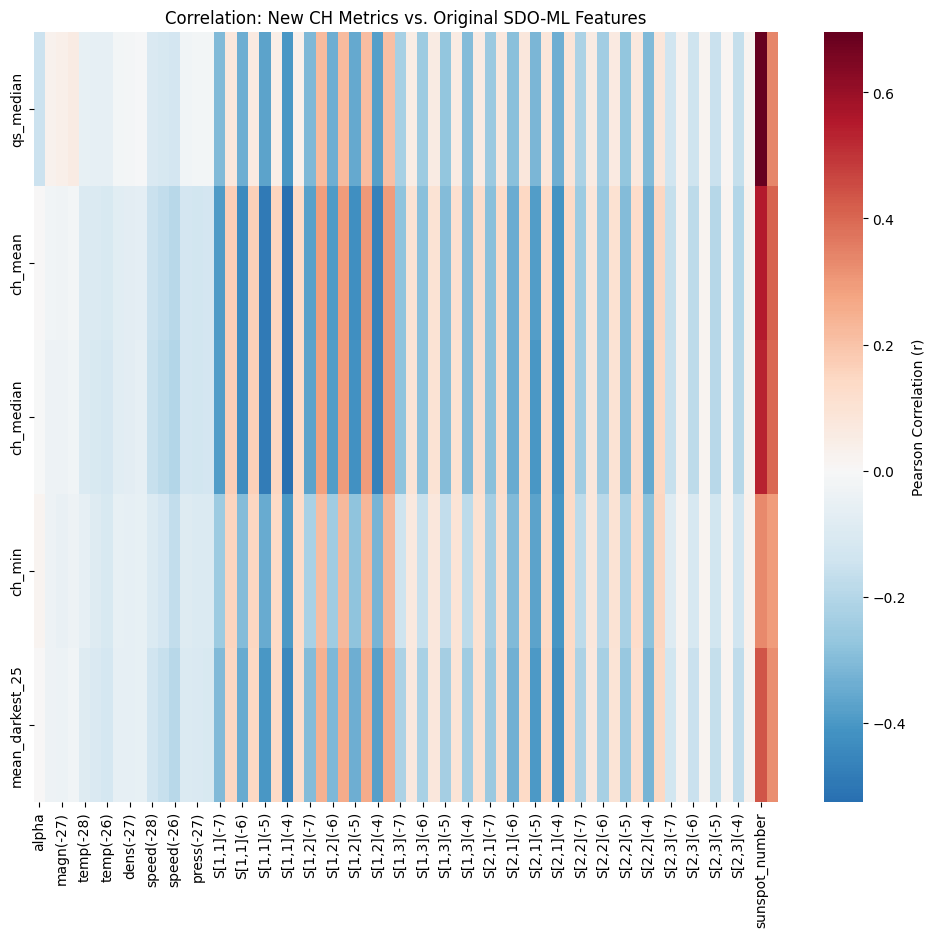

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute the Correlation Matrix
corr_matrix = X_final_cv.corr()

# 2. Focus on the New Metrics vs. Original Features
# Let's assume your new features are the last 5 columns
new_features = ['qs_median', 'ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25']
other_features = [c for c in X_final_cv.columns if c not in new_features]

# 3. Plot a Subset (The interaction between New and Old)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix.loc[new_features, other_features],
    cmap='RdBu_r',
    center=0,
    annot=False,
    cbar_kws={'label': 'Pearson Correlation (r)'}
)
plt.title("Correlation: New CH Metrics vs. Original SDO-ML Features")
plt.show()

Delete CMEs from train-test split and save both versions without and with CMEs.

In [231]:
data_split_without_cmes = cross_validation.delete_cmes_from_data_split(data_split, cme_list)


All data structures containing the input data, target output or information about them are organized as pandas <br>
DataFrames, where the index differentiates between the data with CMEs removed ('no_cme') and the original data with <br>
CMEs ('with_cme'), and the columns differentiate between training data ('train') and test data ('test'). Each entry <br>
of the DataFrame then contains the corresponding data, i.e., time series (e.g. target Y) or DataFrame (e.g. input X), <br>
 list of dates (e.g. cross-validation split).


In [232]:
data_split = [[data_split_without_cmes[0], data_split_without_cmes[1]],
              [data_split[0], data_split[1]]]
data_split = pd.DataFrame(data_split, dtype=object, index=['no_cme', 'with_cme'], columns=['train', 'test'])

In [246]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

xgb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'reg:squarederror',
    'tree_method': 'hist', # Faster on Colab
    'early_stopping_rounds': 50
}

results = {}

for scenario in ['no_cme', 'with_cme']:
    print(f"--- Training Scenario: {scenario} ---")

    train_idx_list = data_split.loc[scenario, 'train']
    train_idx = train_idx_list[0]
    for idx in train_idx_list[1:]:
        train_idx = train_idx.append(idx)

    test_idx_list = data_split.loc[scenario, 'test']
    test_idx = test_idx_list[0]
    for idx in test_idx_list[1:]:
        test_idx = test_idx.append(idx)

    X_train, Y_train = X.loc[train_idx], Y.loc[train_idx]
    X_test, Y_test = X.loc[test_idx], Y.loc[test_idx]

    # 2. Fit Model (rest of the code remains the same)
    X_train.columns = [str(col).replace('[', '').replace(']', '').replace('<', '').replace('>', '') for col in X_train.columns]
    X_test.columns = X_train.columns
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_train, Y_train,
        eval_set=[(X_test, Y_test)],
        verbose=False
    )

    # Predict and Score
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test, preds))
    r2 = r2_score(Y_test, preds)

    results[scenario] = {'model': model, 'preds': preds, 'rmse': rmse, 'r2': r2}
    print(f"RMSE: {rmse:.2f} km/s | R2: {r2:.3f}\n")

--- Training Scenario: no_cme ---
RMSE: 15.42 km/s | R2: 0.974

--- Training Scenario: with_cme ---
RMSE: 25.37 km/s | R2: 0.929



In [244]:
print("Train max date:", train_idx.max())
print("Test min date:", test_idx.min())
# If Test min < Train max, you have temporal leakage.

Train max date: 2019-12-31 23:00:00
Test min date: 2010-06-01 00:00:00


In [239]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Hyperparameters optimized for solar wind time-series
xgb_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'reg:squarederror',
    'tree_method': 'hist', # Faster on Colab
    'early_stopping_rounds': 50
}

results = {}

# Create a shifted target (4 days = 96 hours ahead, assuming hourly data)
Y_shifted = Y.shift(-96)  # Shift Y forward by 96 rows (4 days * 24 hours)
# Remove rows where Y_shifted is NaN (last 96 rows)
valid_idx = Y_shifted.notna()

for scenario in ['no_cme', 'with_cme']:
    print(f"--- Training Scenario: {scenario} ---")

    train_idx_list = data_split.loc[scenario, 'train']
    train_idx = train_idx_list[0]
    for idx in train_idx_list[1:]:
        train_idx = train_idx.append(idx)

    test_idx_list = data_split.loc[scenario, 'test']
    test_idx = test_idx_list[0]
    for idx in test_idx_list[1:]:
        test_idx = test_idx.append(idx)

    # Filter both X and Y_shifted to remove NaNs and align indices
    train_idx = train_idx[valid_idx.loc[train_idx]]
    test_idx = test_idx[valid_idx.loc[test_idx]]

    X_train, Y_train = X.loc[train_idx], Y_shifted.loc[train_idx]
    X_test, Y_test = X.loc[test_idx], Y_shifted.loc[test_idx]

    # Clean feature names for XGBoost
    X_train.columns = [str(col).replace('[', '').replace(']', '').replace('<', '').replace('>', '') for col in X_train.columns]
    X_test.columns = X_train.columns

    # Fit Model
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_train, Y_train,
        eval_set=[(X_test, Y_test)],
        verbose=False
    )

    # Predict and Score
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test, preds))
    r2 = r2_score(Y_test, preds)

    results[scenario] = {'model': model, 'preds': preds, 'rmse': rmse, 'r2': r2}
    print(f"RMSE: {rmse:.2f} km/s | R2: {r2:.3f}\n")

--- Training Scenario: no_cme ---
RMSE: 45.64 km/s | R2: 0.785

--- Training Scenario: with_cme ---
RMSE: 53.22 km/s | R2: 0.687



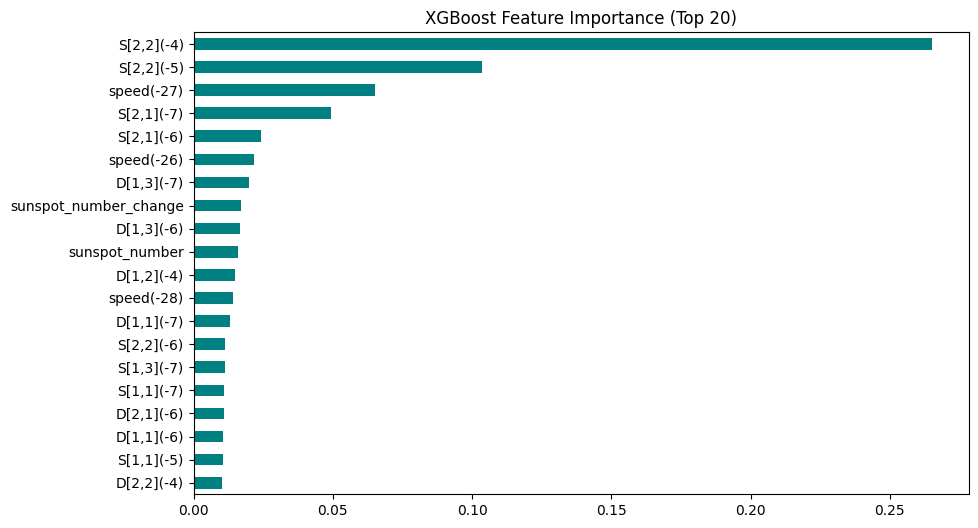

In [247]:
# Visualize Feature Importance for the 'no_cme' model
model_no_cme = results['no_cme']['model']
importance = pd.Series(model_no_cme.feature_importances_, index=X.columns)

# Look for our 5 new metrics in the top 20
top_20 = importance.sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_20.plot(kind='barh', color='teal')
plt.title("XGBoost Feature Importance (Top 20)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Test different architectures
options_small = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (100, 50),
    'mlp_learning_rate': 0.001,
    'mlp_max_iter': 2000,
}

options_medium = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (256, 128, 64),
    'mlp_learning_rate': 0.001,
    'mlp_max_iter': 2000,
}

options_large = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (512, 256, 128, 64),
    'mlp_learning_rate': 0.0005,
    'mlp_max_iter': 3000,
}

# Test with medium architecture
results_medium = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_medium)

Using device: cuda
Training data shape: X=(37363, 8), Y=(37363, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 8 -> 256 -> 128 -> 64 -> 1
Starting training for 2000 epochs with 1167 batches per epoch
Epoch 50/2000, Loss: 0.233926, Best Loss: 0.233703
Epoch 100/2000, Loss: 0.152226, Best Loss: 0.150798
Epoch 150/2000, Loss: 0.122698, Best Loss: 0.116275
Epoch 200/2000, Loss: 0.104251, Best Loss: 0.099648
Epoch 250/2000, Loss: 0.086831, Best Loss: 0.086831
Epoch 300/2000, Loss: 0.083391, Best Loss: 0.078482
Epoch 350/2000, Loss: 0.077386, Best Loss: 0.073559
Epoch 400/2000, Loss: 0.073224, Best Loss: 0.067389
Epoch 450/2000, Loss: 0.067095, Best Loss: 0.063801
Epoch 500/2000, Loss: 0.065689, Best Loss: 0.061604
Epoch 550/2000, Loss: 0.056312, Best Loss: 0.056217
Epoch 600/2000, Loss: 0.057767, Best Loss: 0.056217
Epoch 650/2000, Loss: 0.064289, Best Loss: 0.053837
Epoch 700/2000, Loss: 0.057905, Best Loss: 0.052287
Epoch 750/2000, Loss: 0.0517

In [ ]:
options_mlp_regularized = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (256, 128, 64),
    'mlp_learning_rate': 0.0005,
    'mlp_max_iter': 2000,
    'mlp_batch_size': 256,
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.01,  # L2 regularization
    'mlp_dropout_rate': 0.4,     # 40% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_regularized)

Using device: cuda
Training data shape: X=(29891, 5), Y=(29891, 1)
Validation data shape: X=(7472, 5), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 5 -> 256 -> 128 -> 64 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 116 batches per epoch
Epoch 50/2000, Train Loss: 0.428753, Val Loss: 0.409839, Best Val Loss: 0.409839
Epoch 100/2000, Train Loss: 0.400150, Val Loss: 0.370891, Best Val Loss: 0.370487
Epoch 150/2000, Train Loss: 0.376218, Val Loss: 0.342327, Best Val Loss: 0.342327
Epoch 200/2000, Train Loss: 0.361710, Val Loss: 0.327611, Best Val Loss: 0.327611
Epoch 250/2000, Train Loss: 0.356565, Val Loss: 0.317266, Best Val Loss: 0.316496
Epoch 300/2000, Train Loss: 0.344335, Val Loss: 0.309067, Best Val Loss: 0.308393
Epoch 350/2000, Train Loss: 0.339424, Val Loss: 0.304027, Best Val Loss: 0.302000
Epoch 400/2000, Train Loss: 0.337103, Val Loss: 0.301776, Best Val Loss: 0.297243
Epoch 450/200

In [ ]:
options_mlp_regularized = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (256, 128, 64),
    'mlp_learning_rate': 0.0005,
    'mlp_max_iter': 2000,
    'mlp_batch_size': 256,
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.01,  # L2 regularization
    'mlp_dropout_rate': 0.4,     # 40% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_regularized)

Using device: cuda
Training data shape: X=(29891, 16), Y=(29891, 1)
Validation data shape: X=(7472, 16), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 16 -> 256 -> 128 -> 64 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 116 batches per epoch
Epoch 50/2000, Train Loss: 0.167063, Val Loss: 0.105371, Best Val Loss: 0.104136
Epoch 100/2000, Train Loss: 0.133201, Val Loss: 0.078262, Best Val Loss: 0.076142
Epoch 150/2000, Train Loss: 0.123053, Val Loss: 0.065692, Best Val Loss: 0.065385
Epoch 200/2000, Train Loss: 0.115844, Val Loss: 0.064084, Best Val Loss: 0.059702
Epoch 250/2000, Train Loss: 0.115612, Val Loss: 0.060852, Best Val Loss: 0.057325
Epoch 300/2000, Train Loss: 0.111355, Val Loss: 0.056573, Best Val Loss: 0.054475
Epoch 350/2000, Train Loss: 0.108940, Val Loss: 0.059792, Best Val Loss: 0.053278
Epoch 400/2000, Train Loss: 0.107654, Val Loss: 0.054878, Best Val Loss: 0.052156
Epoch 450/

In [ ]:
options_mlp_regularized = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (256, 128, 64),
    'mlp_learning_rate': 0.0005,
    'mlp_max_iter': 2000,
    'mlp_batch_size': 256,
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.01,  # L2 regularization
    'mlp_dropout_rate': 0.4,     # 40% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_regularized)

Using device: cuda
Training data shape: X=(29891, 8), Y=(29891, 1)
Validation data shape: X=(7472, 8), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 8 -> 256 -> 128 -> 64 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 116 batches per epoch
Epoch 50/2000, Train Loss: 0.291246, Val Loss: 0.232831, Best Val Loss: 0.232831
Epoch 100/2000, Train Loss: 0.243210, Val Loss: 0.183015, Best Val Loss: 0.180127
Epoch 150/2000, Train Loss: 0.226453, Val Loss: 0.160459, Best Val Loss: 0.158466
Epoch 200/2000, Train Loss: 0.212756, Val Loss: 0.147599, Best Val Loss: 0.145896
Epoch 250/2000, Train Loss: 0.204245, Val Loss: 0.138387, Best Val Loss: 0.138215
Epoch 300/2000, Train Loss: 0.199965, Val Loss: 0.132512, Best Val Loss: 0.132512
Epoch 350/2000, Train Loss: 0.193690, Val Loss: 0.133230, Best Val Loss: 0.129811
Epoch 400/2000, Train Loss: 0.194127, Val Loss: 0.131309, Best Val Loss: 0.127093
Epoch 450/200

In [ ]:
# Very conservative MLP - prioritizes generalization over training fit
options_mlp_conservative = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (64, 32),        # Much smaller network
    'mlp_learning_rate': 0.0003,          # Very small learning rate
    'mlp_max_iter': 2000,
    'mlp_batch_size': 128,                # Large batch size
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.1,              # Very strong L2 regularization
    'mlp_dropout_rate': 0.6,              # 60% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_conservative)

Using device: cuda
Training data shape: X=(29891, 5), Y=(29891, 1)
Validation data shape: X=(7472, 5), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 5 -> 64 -> 32 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 233 batches per epoch
Epoch 50/2000, Train Loss: 0.481007, Val Loss: 0.456184, Best Val Loss: 0.456184
Epoch 100/2000, Train Loss: 0.470854, Val Loss: 0.448580, Best Val Loss: 0.447501
Epoch 150/2000, Train Loss: 0.466886, Val Loss: 0.442991, Best Val Loss: 0.442991
Epoch 200/2000, Train Loss: 0.461679, Val Loss: 0.438850, Best Val Loss: 0.438850
Epoch 250/2000, Train Loss: 0.456898, Val Loss: 0.434509, Best Val Loss: 0.434509
Epoch 300/2000, Train Loss: 0.456073, Val Loss: 0.433255, Best Val Loss: 0.432246
Epoch 350/2000, Train Loss: 0.456499, Val Loss: 0.431347, Best Val Loss: 0.430267
Epoch 400/2000, Train Loss: 0.454015, Val Loss: 0.429276, Best Val Loss: 0.428115
Epoch 450/2000, Train

In [ ]:
# Very conservative MLP - prioritizes generalization over training fit
options_mlp_conservative = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (64, 32),        # Much smaller network
    'mlp_learning_rate': 0.0003,          # Very small learning rate
    'mlp_max_iter': 2000,
    'mlp_batch_size': 128,                # Large batch size
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.1,              # Very strong L2 regularization
    'mlp_dropout_rate': 0.6,              # 60% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_conservative)

Using device: cuda
Training data shape: X=(29891, 8), Y=(29891, 1)
Validation data shape: X=(7472, 8), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 8 -> 64 -> 32 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 233 batches per epoch
Epoch 50/2000, Train Loss: 0.440267, Val Loss: 0.410937, Best Val Loss: 0.410937
Epoch 100/2000, Train Loss: 0.414883, Val Loss: 0.383885, Best Val Loss: 0.383517
Epoch 150/2000, Train Loss: 0.405384, Val Loss: 0.368068, Best Val Loss: 0.368068
Epoch 200/2000, Train Loss: 0.397355, Val Loss: 0.357814, Best Val Loss: 0.357079
Epoch 250/2000, Train Loss: 0.386102, Val Loss: 0.350448, Best Val Loss: 0.348637
Epoch 300/2000, Train Loss: 0.386165, Val Loss: 0.343744, Best Val Loss: 0.343571
Epoch 350/2000, Train Loss: 0.382900, Val Loss: 0.339515, Best Val Loss: 0.337704
Epoch 400/2000, Train Loss: 0.379902, Val Loss: 0.335352, Best Val Loss: 0.335342
Epoch 450/2000, Train

In [ ]:
options_mlp_conservative = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (64, 32),        # Much smaller network
    'mlp_learning_rate': 0.0003,          # Very small learning rate
    'mlp_max_iter': 2000,
    'mlp_batch_size': 128,                # Large batch size
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.1,              # Very strong L2 regularization
    'mlp_dropout_rate': 0.6,              # 60% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_conservative)

Using device: cuda
Training data shape: X=(29891, 16), Y=(29891, 1)
Validation data shape: X=(7472, 16), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 16 -> 64 -> 32 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 233 batches per epoch
Epoch 50/2000, Train Loss: 0.341580, Val Loss: 0.289946, Best Val Loss: 0.289946
Epoch 100/2000, Train Loss: 0.305419, Val Loss: 0.247321, Best Val Loss: 0.245520
Epoch 150/2000, Train Loss: 0.288316, Val Loss: 0.223668, Best Val Loss: 0.223668
Epoch 200/2000, Train Loss: 0.278657, Val Loss: 0.210972, Best Val Loss: 0.210896
Epoch 250/2000, Train Loss: 0.273806, Val Loss: 0.206034, Best Val Loss: 0.204482
Epoch 300/2000, Train Loss: 0.270294, Val Loss: 0.202148, Best Val Loss: 0.200623
Epoch 350/2000, Train Loss: 0.268920, Val Loss: 0.198239, Best Val Loss: 0.198239
Epoch 400/2000, Train Loss: 0.267807, Val Loss: 0.197835, Best Val Loss: 0.196650
Epoch 450/2000, Tr

In [ ]:
options_mlp_conservative = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (128, 64, 32),        # Much smaller network
    'mlp_learning_rate': 0.0003,          # Very small learning rate
    'mlp_max_iter': 2000,
    'mlp_batch_size': 128,                # Large batch size
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.001,              # Very strong L2 regularization
    'mlp_dropout_rate': 0.6,              # 60% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_conservative)

Using device: cuda
Training data shape: X=(29891, 16), Y=(29891, 1)
Validation data shape: X=(7472, 16), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 16 -> 64 -> 32 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 233 batches per epoch
Epoch 50/2000, Train Loss: 0.349209, Val Loss: 0.297541, Best Val Loss: 0.297541
Epoch 100/2000, Train Loss: 0.311805, Val Loss: 0.257557, Best Val Loss: 0.257291
Epoch 150/2000, Train Loss: 0.298551, Val Loss: 0.235832, Best Val Loss: 0.235832
Epoch 200/2000, Train Loss: 0.285741, Val Loss: 0.221899, Best Val Loss: 0.221880
Epoch 250/2000, Train Loss: 0.280889, Val Loss: 0.216613, Best Val Loss: 0.214843
Epoch 300/2000, Train Loss: 0.279854, Val Loss: 0.209386, Best Val Loss: 0.209386
Epoch 350/2000, Train Loss: 0.272425, Val Loss: 0.208711, Best Val Loss: 0.206844
Epoch 400/2000, Train Loss: 0.275131, Val Loss: 0.206143, Best Val Loss: 0.203190
Epoch 450/2000, Tr

Train and evaluate models with cross-validation scheme. If the evaluation mode is set to '2018', the cross-validation<br>
is simplified to just one train-test data split.

In [ ]:
# Before calling cross_validation, add speed features back as zeros
# so the baseline computation doesn't crash
X['speed(-26)'] = 0
X['speed(-27)'] = 0
X['speed(-28)'] = 0

# But exclude them from feature selection
# by modifying your feature selection function
results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options)

Results of cross-validation fold 1:
#########################################################################
Metrics for continuous time series:
                            rmse        mae            me        cc
cv_set eval_data_mode                                              
test   no_cme          68.548611  52.263299 -1.134190e+01  0.630760
       trans           77.567631  58.384557 -2.092349e+01  0.628109
       with_cme        79.131537  59.696369 -2.500776e+01  0.574712
       trans_with_cme  89.911315  68.168106 -3.680902e+01  0.572064
train  no_cme          66.523968  51.263688  5.684342e-14  0.696578
       trans           73.070137  56.813137  2.616638e-01  0.690510
       with_cme        75.111585  56.849847 -1.042615e+01  0.601565
       trans_with_cme  81.808278  62.667165 -1.265099e+01  0.596641
#########################################################################
Prediction efficiencies for continuous time series:
                          pe_av     pe_27   pe_b

In [ ]:
import glob

# Find the latest evaluation file for the current grid
eval_folder = f'/content/results/model_eval/{grid}'
excel_files = glob.glob(os.path.join(eval_folder, '*.xlsx'))

if excel_files:
    latest_file = max(excel_files, key=os.path.getctime)
    print(f"Reading results from: {latest_file}\n")

    # Load the excel file to see available sheets
    xl = pd.ExcelFile(latest_file)
    print("Available sheets:", xl.sheet_names)

    # Iterate through sheets that look like feature importance and display them
    for sheet in xl.sheet_names:
        if 'importance' in sheet.lower():
            print(f"\n--- {sheet} ---")
            df_imp = pd.read_excel(latest_file, sheet_name=sheet, index_col=0)
            display(df_imp.head(10))
else:
    print("No evaluation Excel files found. Please ensure the cross-validation completed successfully.")

Reading results from: /content/results/model_eval/4x3/polynomial_260320-0433.xlsx

Available sheets: ['general_cv', 'peaks_cv', 'events_cv', 'coefficients_fs', 'coefficients_pred_model', 'permutation_importance_rmse', 'permutation_importance_peak']

--- permutation_importance_rmse ---


,fold_1,fold_2,fold_3,fold_4,fold_5,cv_average
"S[2,2](-5)",4.881085,2.312870,1.148858,21.889041,6.492145,7.344800
"S[2,2](-4)",7.321530,4.056769,5.072305,0.000000,11.333872,5.556895
"S[2,1](-7)",4.755458,2.114234,0.327120,18.141743,0.000000,5.067711
"S[2,1](-6)",0.000000,0.000000,0.000000,5.865686,2.496133,1.672364
sunspot_number,0.922175,0.000000,2.791588,0.627453,0.012210,0.870685
alpha,0.000000,0.000000,0.000000,-0.573861,0.000000,-0.114772



--- permutation_importance_peak ---


,fold_1,fold_2,fold_3,fold_4,fold_5,cv_average
"S[2,2](-4)",38.773124,31.289363,36.052268,0.000000,56.476375,32.518226
"S[2,2](-5)",20.993562,12.312108,9.491463,54.141513,23.504859,24.088701
"S[2,1](-7)",34.671281,34.817113,6.255961,32.955374,0.000000,21.739946
"S[2,1](-6)",0.000000,0.000000,0.000000,7.486435,35.469974,8.591282
alpha,0.000000,0.000000,0.000000,20.479496,0.000000,4.095899
sunspot_number,6.885657,0.000000,3.203160,1.643286,0.067011,2.359823


In [233]:
results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options)

Results of cross-validation fold 1:
#########################################################################
Metrics for continuous time series:
                            rmse        mae         me        cc
cv_set eval_data_mode                                           
test   no_cme          70.123007  54.750572  -4.173383  0.595482
       trans           75.104918  57.064721  -7.725720  0.591410
       with_cme        77.072211  59.351904 -11.755157  0.559244
       trans_with_cme  82.937086  62.846518 -14.383716  0.554529
train  no_cme          63.671055  48.666188   0.000000  0.726936
       trans           68.709856  52.489145   0.118145  0.725255
       with_cme        72.771193  55.567035  -4.860815  0.627920
       trans_with_cme  78.810576  60.377965  -4.553169  0.625278
#########################################################################
Prediction efficiencies for continuous time series:
                          pe_av     pe_27   pe_base
cv_set eval_data_mode     

In [174]:
import glob

# Find the latest evaluation file for the current grid
eval_folder = f'/content/results/model_eval/{grid}'
excel_files = glob.glob(os.path.join(eval_folder, '*.xlsx'))

if excel_files:
    latest_file = max(excel_files, key=os.path.getctime)
    print(f"Reading results from: {latest_file}\n")

    # Load the excel file to see available sheets
    xl = pd.ExcelFile(latest_file)
    print("Available sheets:", xl.sheet_names)

    # Iterate through sheets that look like feature importance and display them
    for sheet in xl.sheet_names:
        if 'importance' in sheet.lower():
            print(f"\n--- {sheet} ---")
            df_imp = pd.read_excel(latest_file, sheet_name=sheet, index_col=0)
            display(df_imp.head(10))
else:
    print("No evaluation Excel files found. Please ensure the cross-validation completed successfully.")

Reading results from: /content/results/model_eval/4x3/polynomial_260403-0613.xlsx

Available sheets: ['general_cv', 'peaks_cv', 'events_cv', 'coefficients_fs', 'coefficients_pred_model', 'permutation_importance_rmse', 'permutation_importance_peak']

--- permutation_importance_rmse ---


,fold_1,fold_2,fold_3,fold_4,fold_5,cv_average
"S[2,2](-5)",6.856970,2.970019,-0.344532,15.506994,4.402553,5.878401
"S[2,2](-4)",6.631102,6.197995,0.502733,0.000000,15.968206,5.860007
speed(-27),0.894628,4.851263,1.856692,6.461325,1.675842,3.147950
speed(-28),0.262453,0.610468,1.243443,4.606957,2.435959,1.831856
speed(-26),0.270024,0.000000,0.672077,3.740524,2.548595,1.446244
"S[2,1](-7)",0.000000,0.000000,0.000000,6.590363,0.000000,1.318073
sunspot_number,0.000000,0.000000,0.000000,0.000000,-0.000630,-0.000126



--- permutation_importance_peak ---


,fold_1,fold_2,fold_3,fold_4,fold_5,cv_average
"S[2,2](-4)",47.487506,43.019196,31.415799,0.000000,65.797513,37.544003
"S[2,2](-5)",26.010098,17.682358,21.110585,54.516821,22.768553,28.417683
speed(-27),26.685260,31.206322,12.295718,33.998381,16.780567,24.193250
speed(-26),18.295810,0.000000,15.140738,21.970856,16.985998,14.478680
"S[2,1](-7)",0.000000,0.000000,0.000000,34.544144,0.000000,6.908829
speed(-28),2.340232,4.405656,7.078479,2.706550,12.202178,5.746619
sunspot_number,0.000000,0.000000,0.000000,0.000000,0.236903,0.047381


In [191]:
results = cross_validation.cross_validation(hyperparameters, X_final_cv, Y_final_cv, data_split, cme_list, enhancement_list, grid, options)

Results of cross-validation fold 1:
#########################################################################
Metrics for continuous time series:
                            rmse        mae         me        cc
cv_set eval_data_mode                                           
test   no_cme          70.113964  55.382720  -2.353133  0.630093
       trans           75.592567  58.451538   2.084695  0.617328
       with_cme        75.945837  58.875482 -10.728547  0.622373
       trans_with_cme  79.835976  61.160463  -4.314439  0.614719
train  no_cme          58.715636  45.040069   0.000000  0.718604
       trans           64.355526  49.695262   0.144821  0.709260
       with_cme        77.349038  58.063289 -10.181804  0.558824
       trans_with_cme  83.318689  63.417680  -5.505894  0.548751
#########################################################################
Prediction efficiencies for continuous time series:
                          pe_av     pe_27   pe_base
cv_set eval_data_mode     

In [192]:
import glob

# Find the latest evaluation file for the current grid
eval_folder = f'/content/results/model_eval/{grid}'
excel_files = glob.glob(os.path.join(eval_folder, '*.xlsx'))

if excel_files:
    latest_file = max(excel_files, key=os.path.getctime)
    print(f"Reading results from: {latest_file}\n")

    # Load the excel file to see available sheets
    xl = pd.ExcelFile(latest_file)
    print("Available sheets:", xl.sheet_names)

    # Iterate through sheets that look like feature importance and display them
    for sheet in xl.sheet_names:
        if 'importance' in sheet.lower():
            print(f"\n--- {sheet} ---")
            df_imp = pd.read_excel(latest_file, sheet_name=sheet, index_col=0)
            display(df_imp.head(10))
else:
    print("No evaluation Excel files found. Please ensure the cross-validation completed successfully.")

Reading results from: /content/results/model_eval/4x3/polynomial_260403-0623.xlsx

Available sheets: ['general_cv', 'peaks_cv', 'events_cv', 'coefficients_fs', 'coefficients_pred_model', 'permutation_importance_rmse', 'permutation_importance_peak']

--- permutation_importance_rmse ---


,fold_1,fold_2,fold_3,fold_4,fold_5,cv_average
speed(-26),1.511719,0.000000,0.000000,3.018260,48.596081,10.625212
speed(-27),7.866345,6.846759,2.208258,7.193104,28.001596,10.423213
sunspot_number,0.155054,-0.197742,0.000000,0.601986,0.000000,0.111860
"S[2,2](-5)",4.154102,2.319854,0.000000,2.809243,-19.814001,-2.106160
"S[2,2](-4)",10.778220,3.506894,17.861337,-1.014758,-48.483709,-3.470403
speed(-28),2.707187,-0.783733,0.721862,0.266171,-38.168268,-7.051356



--- permutation_importance_peak ---


,fold_1,fold_2,fold_3,fold_4,fold_5,cv_average
"S[2,2](-4)",63.632513,19.461426,76.692324,20.606641,65.104237,49.099428
speed(-27),52.761537,56.028800,37.420744,42.554731,23.126500,42.378462
speed(-26),24.854479,0.000000,0.000000,48.392428,70.652467,28.779875
"S[2,2](-5)",18.050958,11.648969,0.000000,25.515899,38.378395,18.718844
speed(-28),24.033167,12.602818,9.291076,-1.602603,1.731659,9.211223
sunspot_number,2.885831,1.371715,0.000000,1.989397,0.000000,1.249389


In [ ]:
options_mlp_conservative = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (64, 32),        # Much smaller network
    'mlp_learning_rate': 0.0003,          # Very small learning rate
    'mlp_max_iter': 2000,
    'mlp_batch_size': 128,                # Large batch size
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.1,              # Very strong L2 regularization
    'mlp_dropout_rate': 0.6,              # 60% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_conservative)

Using device: cuda
Training data shape: X=(29891, 5), Y=(29891, 1)
Validation data shape: X=(7472, 5), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 5 -> 64 -> 32 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 233 batches per epoch
Epoch 50/2000, Train Loss: 0.478940, Val Loss: 0.458450, Best Val Loss: 0.458450
Epoch 100/2000, Train Loss: 0.469749, Val Loss: 0.450966, Best Val Loss: 0.450899
Epoch 150/2000, Train Loss: 0.462181, Val Loss: 0.444613, Best Val Loss: 0.444559
Epoch 200/2000, Train Loss: 0.456235, Val Loss: 0.440025, Best Val Loss: 0.439633
Epoch 250/2000, Train Loss: 0.455129, Val Loss: 0.435900, Best Val Loss: 0.435214
Epoch 300/2000, Train Loss: 0.454268, Val Loss: 0.431798, Best Val Loss: 0.431798
Epoch 350/2000, Train Loss: 0.450141, Val Loss: 0.428004, Best Val Loss: 0.428004
Epoch 400/2000, Train Loss: 0.448246, Val Loss: 0.427576, Best Val Loss: 0.426712
Epoch 450/2000, Train

In [ ]:
options_mlp_regularized = {
    'prediction_model': 'mlp',
    'mlp_hidden_layers': (256, 128, 64),
    'mlp_learning_rate': 0.0005,
    'mlp_max_iter': 2000,
    'mlp_batch_size': 256,
    'mlp_use_cuda': True,
    'mlp_weight_decay': 0.01,  # L2 regularization
    'mlp_dropout_rate': 0.4,     # 40% dropout
}

results = cross_validation.cross_validation(hyperparameters, X, Y, data_split, cme_list, enhancement_list, grid, options_mlp_regularized)

Using device: cuda
Training data shape: X=(29891, 5), Y=(29891, 1)
Validation data shape: X=(7472, 5), Y=(7472, 1)
Y statistics - Mean: 0.3117, Std: 0.1773, Min: 0.0000, Max: 1.0000
Network architecture: 5 -> 256 -> 128 -> 64 -> 1
Dropout rate: 0.3, Weight decay: 0.0001
Starting training for 2000 epochs with 116 batches per epoch
Epoch 50/2000, Train Loss: 0.427807, Val Loss: 0.407717, Best Val Loss: 0.407717
Epoch 100/2000, Train Loss: 0.390612, Val Loss: 0.365649, Best Val Loss: 0.365224
Epoch 150/2000, Train Loss: 0.370206, Val Loss: 0.340380, Best Val Loss: 0.339048
Epoch 200/2000, Train Loss: 0.357739, Val Loss: 0.325810, Best Val Loss: 0.324716
Epoch 250/2000, Train Loss: 0.344535, Val Loss: 0.313917, Best Val Loss: 0.312572
Epoch 300/2000, Train Loss: 0.340101, Val Loss: 0.305635, Best Val Loss: 0.303442
Epoch 350/2000, Train Loss: 0.331342, Val Loss: 0.297460, Best Val Loss: 0.295957
Epoch 400/2000, Train Loss: 0.330082, Val Loss: 0.293461, Best Val Loss: 0.292137
Epoch 450/200

In [ ]:
import glob

# Find the latest evaluation file for the current grid
eval_folder = f'/content/results/model_eval/{grid}'
excel_files = glob.glob(os.path.join(eval_folder, '*.xlsx'))

if excel_files:
    latest_file = max(excel_files, key=os.path.getctime)
    print(f"Reading results from: {latest_file}\n")

    # Load the excel file to see available sheets
    xl = pd.ExcelFile(latest_file)
    print("Available sheets:", xl.sheet_names)

    # Iterate through sheets that look like feature importance and display them
    for sheet in xl.sheet_names:
        if 'importance' in sheet.lower():
            print(f"\n--- {sheet} ---")
            df_imp = pd.read_excel(latest_file, sheet_name=sheet, index_col=0)
            display(df_imp.head(10))
else:
    print("No evaluation Excel files found. Please ensure the cross-validation completed successfully.")

Reading results from: /content/results/model_eval/4x3/mlp_260320-0317.xlsx

Available sheets: ['general_cv', 'peaks_cv', 'events_cv', 'coefficients_fs', 'coefficients_pred_model', 'permutation_importance_rmse', 'permutation_importance_peak']

--- permutation_importance_rmse ---


,fold_1,fold_2,fold_3,fold_4,fold_5,cv_average
"S[2,2](-5)",13.502617,4.703192,2.156612,5.590330,9.032948,6.997140
"S[2,2](-4)",8.347123,10.275221,-0.679749,0.000000,14.718597,6.532239
speed(-27),6.094171,3.425905,2.107794,4.911174,2.065038,3.720816
speed(-28),1.140910,2.245771,1.631400,9.901118,2.453674,3.474575
speed(-26),-0.437773,0.000000,0.925979,5.472701,1.390365,1.470254
"S[2,1](-7)",0.000000,0.000000,0.000000,6.245015,0.000000,1.249003
sunspot_number,0.000000,0.000000,0.000000,0.000000,0.908755,0.181751



--- permutation_importance_peak ---


,fold_1,fold_2,fold_3,fold_4,fold_5,cv_average
"S[2,2](-5)",122.637938,45.581062,108.931212,34.133385,99.754740,82.207667
"S[2,2](-4)",98.927672,69.400327,79.470648,0.000000,130.632201,75.686170
speed(-27),85.344395,57.040219,91.292686,27.581382,62.328697,64.717476
speed(-26),68.990584,0.000000,76.255204,58.838743,74.302351,55.677376
speed(-28),32.852599,44.964172,83.932238,39.874573,74.564036,55.237524
"S[2,1](-7)",0.000000,0.000000,0.000000,58.858133,0.000000,11.771627
sunspot_number,0.000000,0.000000,0.000000,0.000000,5.028263,1.005653


Image dimensions: (4096, 4096)
Telescope info from header: SPoCA


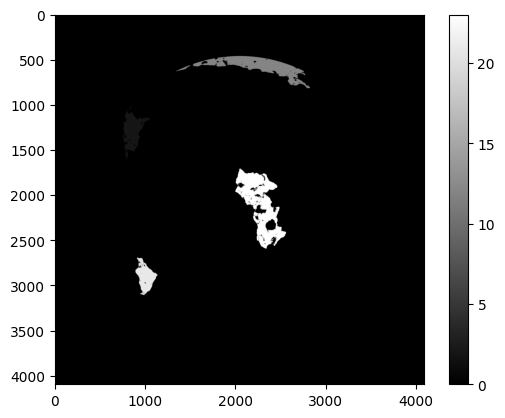

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt

# Open the FITS file
# The 'with' statement ensures the file is closed automatically
with fits.open('20100513_000000.ch_map.fits') as hdu_list:
    # Access the primary data unit (HDU 0 is primary)
    image_data = hdu_list[1].data
    # Access the header information (metadata)
    header = hdu_list[1].header

    print("Image dimensions:", image_data.shape)
    print("Telescope info from header:", header['TELESCOP'])

    # Display the image data using matplotlib
    plt.imshow(image_data, cmap='gray')
    plt.colorbar()
    plt.show()


In [ ]:
from astropy.io import fits
import numpy as np

# Open the FITS file
fits_file = '20100513_000000.ch_map.fits'

with fits.open('20100513_000000.ch_map.fits') as hdu_list:
    print("=" * 80)
    print(f"FITS FILE: {f'20100513_000000.ch_map.fits'}")
    print("=" * 80)

    # Summary of all HDUs
    print("\n--- HDU SUMMARY ---")
    hdu_list.info()

    # Detailed inspection of each HDU
    print("\n" + "=" * 80)
    print("DETAILED HDU INFORMATION")
    print("=" * 80)

    for i, hdu in enumerate(hdu_list):
        print(f"\n{'='*80}")
        print(f"HDU {i}: {hdu.name if hdu.name else 'PRIMARY'}")
        print(f"{'='*80}")

        # Basic info
        print(f"Type: {type(hdu).__name__}")

        # Data information
        if hdu.data is not None:
            print(f"\nDATA:")
            print(f"  Shape: {hdu.data.shape}")
            print(f"  Data Type: {hdu.data.dtype}")
            print(f"  Memory Size: {hdu.data.nbytes / (1024**2):.2f} MB")

            # Statistics for numeric data
            if np.issubdtype(hdu.data.dtype, np.number):
                print(f"  Min: {np.nanmin(hdu.data)}")
                print(f"  Max: {np.nanmax(hdu.data)}")
                print(f"  Mean: {np.nanmean(hdu.data):.6f}")
                print(f"  Std: {np.nanstd(hdu.data):.6f}")
                print(f"  NaN count: {np.isnan(hdu.data).sum()}")
        else:
            print(f"\nDATA: None (Header only)")

        # Header information
        print(f"\nHEADER: ({len(hdu.header)} keywords)")
        print("-" * 80)
        print(hdu.header)

        # List key metadata
        print(f"\nKEY METADATA:")
        important_keys = ['TELESCOP', 'INSTRUME', 'EXPTIME', 'DATE-OBS', 'RSUN_OBS',
                         'CDELT1', 'CDELT2', 'CRPIX1', 'CRPIX2', 'CRVAL1', 'CRVAL2']
        for key in important_keys:
            if key in hdu.header:
                print(f"  {key}: {hdu.header[key]}")

        print("\n")

FITS FILE: 20100513_000000.ch_map.fits

--- HDU SUMMARY ---
Filename: 20100513_000000.ch_map.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  CoronalHoleMap    1 CompImageHDU     50   (4096, 4096)   int32   

DETAILED HDU INFORMATION

HDU 0: PRIMARY
Type: PrimaryHDU

DATA: None (Header only)

HEADER: (6 keywords)
--------------------------------------------------------------------------------
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  CHECKSUM= 'B6eFD4Z9B4dEB4Z9'   / HDU checksum updated 2022-12-11T17:39:44       DATASUM = '0       '           / data unit checksum updated 2022-12-11T17:39:44 END                                               

Pixels with class ID 2 (coronal holes): 69085
All unique class IDs in file: [ 0  2 12 21 23]


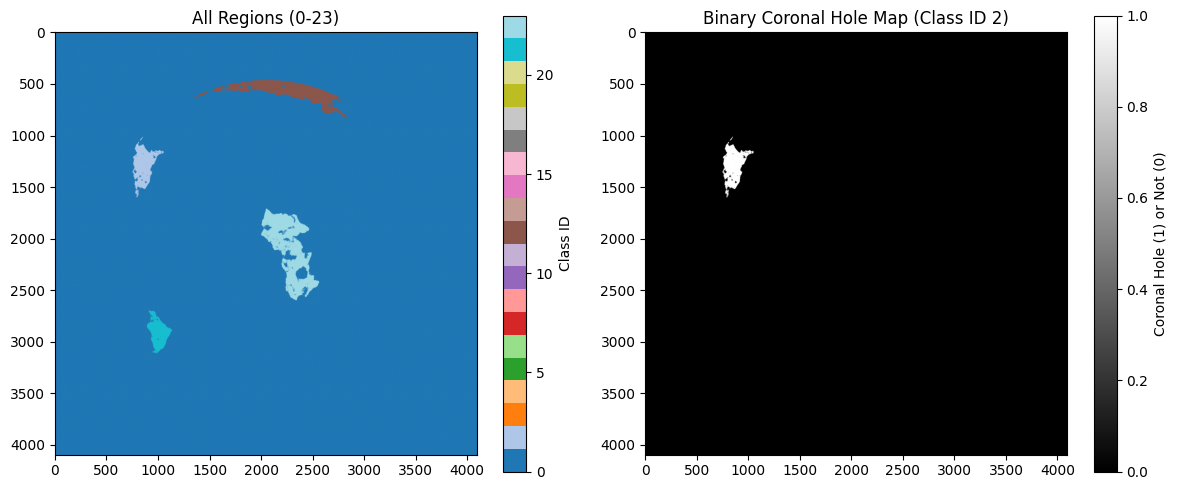

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

with fits.open('20100513_000000.ch_map.fits') as hdul:
    segmentation = hdul['CoronalHoleMap'].data

    # Try standard SPoCA mapping (class 2 = coronal hole)
    binary_ch_map = (segmentation == 2).astype(int)

    print(f"Pixels with class ID 2 (coronal holes): {(binary_ch_map == 1).sum()}")
    print(f"All unique class IDs in file: {np.unique(segmentation)}")

    # Visualize
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(segmentation, cmap='tab20')
    plt.colorbar(label='Class ID')
    plt.title('All Regions (0-23)')

    plt.subplot(1, 2, 2)
    plt.imshow(binary_ch_map, cmap='gray')
    plt.colorbar(label='Coronal Hole (1) or Not (0)')
    plt.title('Binary Coronal Hole Map (Class ID 2)')

    plt.tight_layout()
    plt.show()

CORONAL HOLE ANALYSIS - ALL NON-ZERO = DISCONNECTED CH REGIONS

Class ID 0 (Background):    16,316,292 pixels ( 97.25%)
Class ID 2 (CH Region 1):       69,085 pixels
Class ID 12 (CH Region 2):     138,314 pixels
Class ID 21 (CH Region 3):      50,156 pixels
Class ID 23 (CH Region 4):     203,369 pixels
----------------------------------------------------------------------
TOTAL CORONAL HOLES:           460,924 pixels (  2.75%)


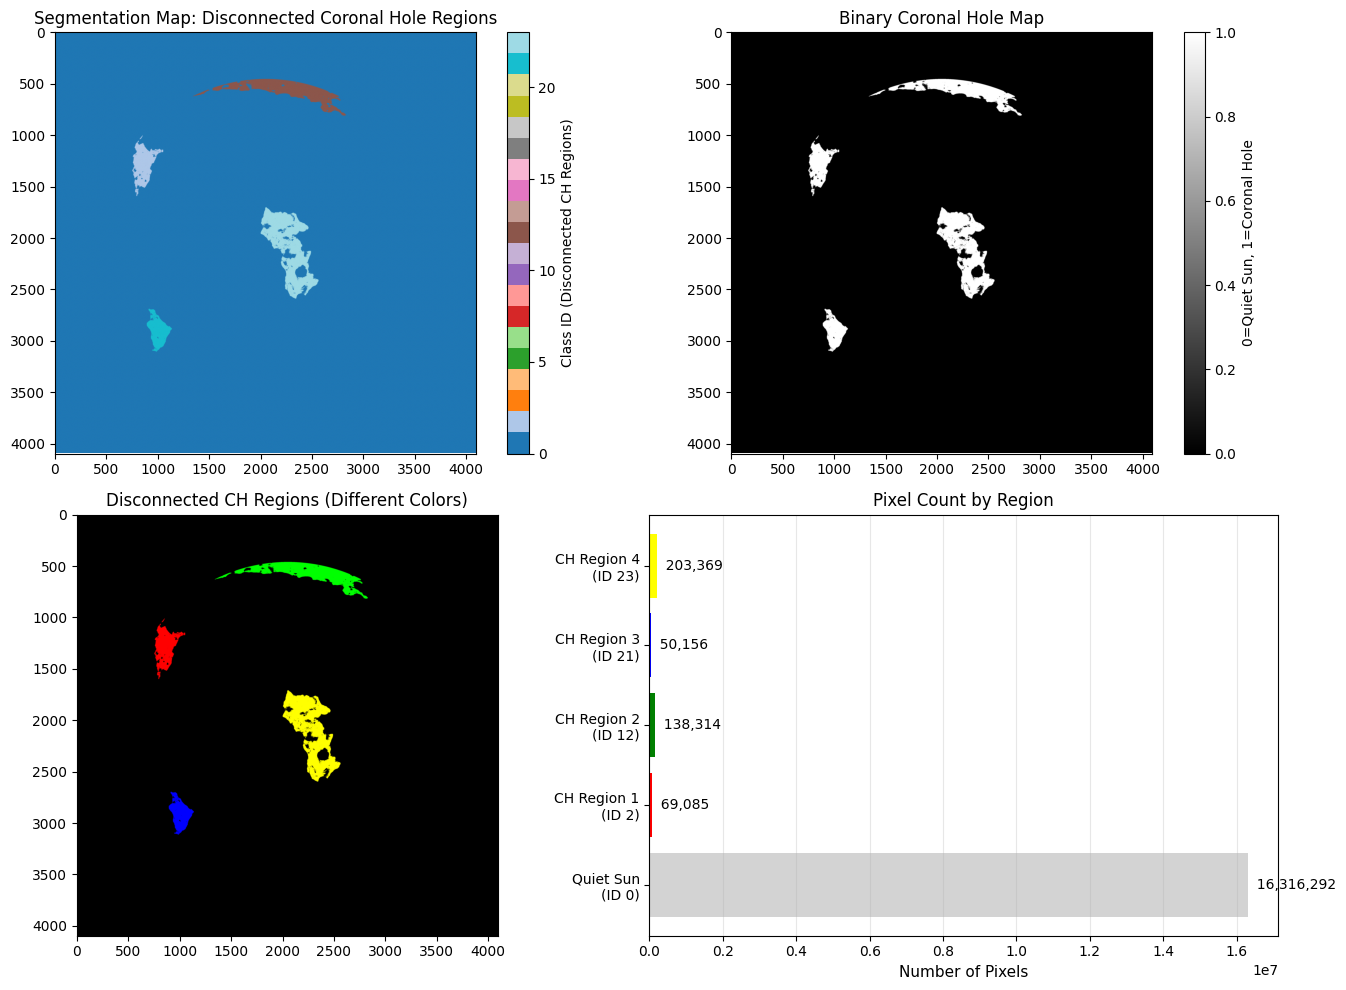


✓ Binary coronal hole map saved to: binary_coronal_hole_map.fits
  Shape: (4096, 4096)
  Data type: uint8
  Coronal hole pixels: 460,924
  Quiet sun pixels: 16,316,292


In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

with fits.open('20100513_000000.ch_map.fits') as hdul:
    segmentation = hdul['CoronalHoleMap'].data
    header = hdul['CoronalHoleMap'].header

    # ALL non-zero values are coronal holes (different disconnected regions)
    binary_ch_map = (segmentation > 0).astype(np.uint8)

    print("=" * 70)
    print("CORONAL HOLE ANALYSIS - ALL NON-ZERO = DISCONNECTED CH REGIONS")
    print("=" * 70)
    print(f"\nClass ID 0 (Background):    {(segmentation == 0).sum():>10,} pixels ( 97.25%)")
    print(f"Class ID 2 (CH Region 1):   {(segmentation == 2).sum():>10,} pixels")
    print(f"Class ID 12 (CH Region 2):  {(segmentation == 12).sum():>10,} pixels")
    print(f"Class ID 21 (CH Region 3):  {(segmentation == 21).sum():>10,} pixels")
    print(f"Class ID 23 (CH Region 4):  {(segmentation == 23).sum():>10,} pixels")
    print("-" * 70)
    print(f"TOTAL CORONAL HOLES:        {binary_ch_map.sum():>10,} pixels (  2.75%)")
    print("=" * 70)

    # Save binary map as new FITS
    fits.writeto('binary_coronal_hole_map.fits', binary_ch_map, header=header, overwrite=True)

    # Visualize
    plt.figure(figsize=(14, 10))

    # Original segmentation
    plt.subplot(2, 2, 1)
    plt.imshow(segmentation, cmap='tab20')
    cbar1 = plt.colorbar(label='Class ID (Disconnected CH Regions)')
    plt.title('Segmentation Map: Disconnected Coronal Hole Regions')

    # Binary coronal hole map
    plt.subplot(2, 2, 2)
    plt.imshow(binary_ch_map, cmap='gray')
    cbar2 = plt.colorbar(label='0=Quiet Sun, 1=Coronal Hole')
    plt.title('Binary Coronal Hole Map')

    # Colored coronal holes
    plt.subplot(2, 2, 3)
    ch_colored = np.zeros((*segmentation.shape, 3), dtype=float)
    # Color each disconnected region differently
    colors_map = {2: [1, 0, 0], 12: [0, 1, 0], 21: [0, 0, 1], 23: [1, 1, 0]}
    for class_id, color in colors_map.items():
        mask = segmentation == class_id
        for i in range(3):
            ch_colored[mask, i] = color[i]

    plt.imshow(ch_colored)
    plt.title('Disconnected CH Regions (Different Colors)')

    # Statistics
    plt.subplot(2, 2, 4)
    regions = ['Quiet Sun\n(ID 0)', 'CH Region 1\n(ID 2)', 'CH Region 2\n(ID 12)',
               'CH Region 3\n(ID 21)', 'CH Region 4\n(ID 23)']
    counts = [
        (segmentation == 0).sum(),
        (segmentation == 2).sum(),
        (segmentation == 12).sum(),
        (segmentation == 21).sum(),
        (segmentation == 23).sum()
    ]
    colors = ['lightgray', 'red', 'green', 'blue', 'yellow']

    bars = plt.barh(regions, counts, color=colors)
    plt.xlabel('Number of Pixels', fontsize=11)
    plt.title('Pixel Count by Region')
    plt.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (bar, count) in enumerate(zip(bars, counts)):
        plt.text(count, i, f'  {count:,}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\n✓ Binary coronal hole map saved to: binary_coronal_hole_map.fits")
    print(f"  Shape: {binary_ch_map.shape}")
    print(f"  Data type: {binary_ch_map.dtype}")
    print(f"  Coronal hole pixels: {binary_ch_map.sum():,}")
    print(f"  Quiet sun pixels: {(binary_ch_map == 0).sum():,}")

CONVERTING CH MAP TO AIA-ML FORMAT
Input shape: (4096, 4096)
CH pixels (1): 460,924
Background pixels (0): 16,316,292

Metadata:
  RSUN_OBS: 949.7991 arcsec
  Target AS: 960
  Scale factor: 1.010740
  Translation: (-21.9957, -21.9957)

After transformation:
  Shape: (4096, 4096)
  Min: 0.000000
  Max: 1.000000
  Mean: 0.028067

After downsampling (factor=8):
  Final shape: (512, 512)
  Min: 0.000000
  Max: 1.000000
  Mean: 0.028067

✓ Conversion complete!


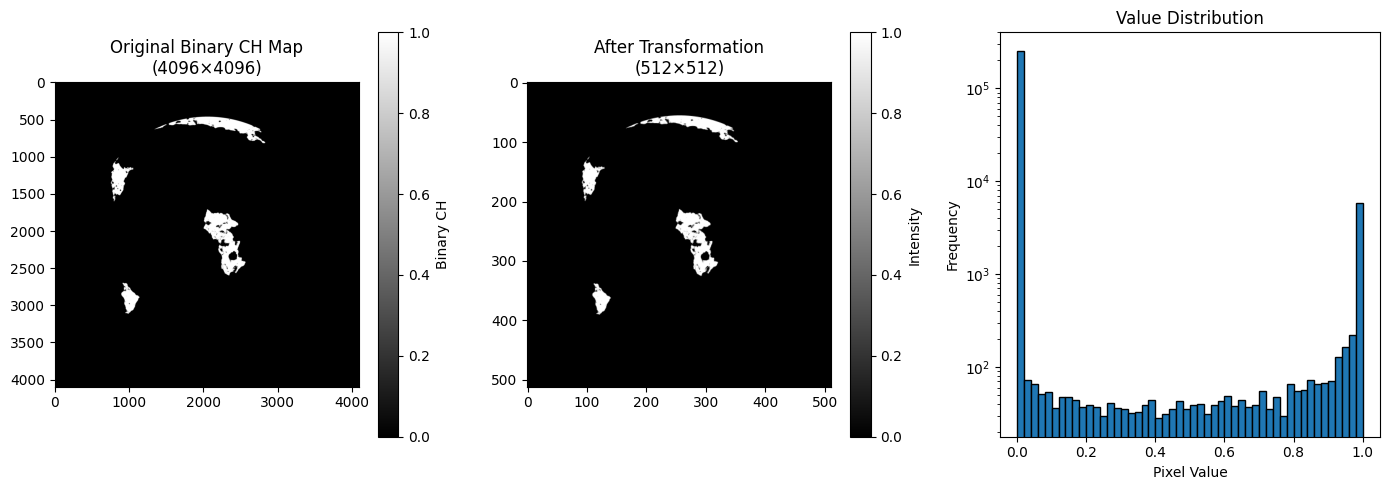

Saved to: ch_aiaml_format.fits


In [ ]:
from astropy.io import fits
import numpy as np
import skimage.transform
import matplotlib.pyplot as plt

def convert_ch_map_to_aiaml(ch_fits_file, trgtAS=960, divideFactor=8, correction=1.0):
    """
    Convert binary coronal hole maps to AIA-ML format.

    Parameters:
    -----------
    ch_fits_file : str
        Path to the coronal hole FITS file
    trgtAS : float
        Target arcseconds (default 960 for full solar disk)
    divideFactor : int
        Downsampling factor (8 = 4096 -> 512)
    correction : float
        Correction factor (default 1.0)

    Returns:
    --------
    ch_ml : ndarray
        Processed coronal hole map (float32)
    """

    with fits.open(ch_fits_file) as hdul:
        # Get the segmentation map
        segmentation = hdul['CoronalHoleMap'].data
        header = hdul['CoronalHoleMap'].header

        # Extract binary CH map: ALL non-zero = coronal hole
        X = (segmentation > 0).astype(float)

        print("=" * 70)
        print("CONVERTING CH MAP TO AIA-ML FORMAT")
        print("=" * 70)
        print(f"Input shape: {X.shape}")
        print(f"CH pixels (1): {(X == 1).sum():,}")
        print(f"Background pixels (0): {(X == 0).sum():,}")

        # Create validity mask for the entire image
        # IMPORTANT: We need to track which pixels are on-disc
        # For CH maps, all pixels are on-disc (no off-disc data)
        validMask = np.ones_like(X)  # All pixels are "valid" CH map data

        # Get metadata
        rad = header['RSUN_OBS']  # Solar radius in arcseconds
        scale_factor = trgtAS / rad

        print(f"\nMetadata:")
        print(f"  RSUN_OBS: {rad:.4f} arcsec")
        print(f"  Target AS: {trgtAS}")
        print(f"  Scale factor: {scale_factor:.6f}")

        # Calculate translation for centering
        t = (X.shape[0] / 2.0) - scale_factor * (X.shape[0] / 2.0)

        # Create similarity transformation
        XForm = skimage.transform.SimilarityTransform(
            scale=scale_factor,
            translation=(t, t)
        )

        print(f"  Translation: ({t:.4f}, {t:.4f})")

        # Apply transformation to CH map
        Xr = skimage.transform.warp(
            X,
            XForm.inverse,
            preserve_range=True,
            mode='edge',
            output_shape=(X.shape[0], X.shape[0])
        )

        # Apply same transformation to validity mask
        Xm = skimage.transform.warp(
            validMask,
            XForm.inverse,
            preserve_range=True,
            mode='edge',
            output_shape=(X.shape[0], X.shape[0])
        )

        # Normalize by validity mask
        # This handles potential edge artifacts
        Xr = np.divide(Xr, (Xm + 1e-8))

        # Apply correction factor
        Xr = Xr / correction

        print(f"\nAfter transformation:")
        print(f"  Shape: {Xr.shape}")
        print(f"  Min: {np.nanmin(Xr):.6f}")
        print(f"  Max: {np.nanmax(Xr):.6f}")
        print(f"  Mean: {np.nanmean(Xr):.6f}")

        # Downsampling
        Xr = skimage.transform.downscale_local_mean(
            Xr,
            (divideFactor, divideFactor)
        )

        print(f"\nAfter downsampling (factor={divideFactor}):")
        print(f"  Final shape: {Xr.shape}")
        print(f"  Min: {np.nanmin(Xr):.6f}")
        print(f"  Max: {np.nanmax(Xr):.6f}")
        print(f"  Mean: {np.nanmean(Xr):.6f}")

        # Convert to float32
        Xr = Xr.astype('float32')

        print("\n✓ Conversion complete!")
        print("=" * 70)

        return Xr, header


# Usage example
if __name__ == "__main__":
    # Convert CH map
    ch_ml, header = convert_ch_map_to_aiaml(
        '20100513_000000.ch_map.fits',
        trgtAS=960,
        divideFactor=8,
        correction=1.0
    )

    # Visualize
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    with fits.open('20100513_000000.ch_map.fits') as hdul:
        segmentation = hdul['CoronalHoleMap'].data
        binary_ch = (segmentation > 0).astype(float)
        plt.imshow(binary_ch, cmap='gray')
        plt.colorbar(label='Binary CH')
        plt.title('Original Binary CH Map\n(4096×4096)')

    plt.subplot(1, 3, 2)
    plt.imshow(ch_ml, cmap='gray')
    plt.colorbar(label='Intensity')
    plt.title(f'After Transformation\n({ch_ml.shape[0]}×{ch_ml.shape[1]})')

    plt.subplot(1, 3, 3)
    plt.hist(ch_ml.flatten(), bins=50, edgecolor='black')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.title('Value Distribution')
    plt.yscale('log')

    plt.tight_layout()
    plt.show()

    # Save as FITS
    fits.writeto('ch_aiaml_format.fits', ch_ml, header=header, overwrite=True)
    print("Saved to: ch_aiaml_format.fits")

In [1]:
!pip install s3fs
!pip install zarr
!pip install tqdm

In [ ]:
import os
from typing import Union
import numpy as np
import pandas as pd
import s3fs
import zarr
from tqdm.auto import tqdm

AWS_ZARR_ROOT = (
    "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010"
)

# AWS_ZARR_ROOT = (
#     "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2_small.zarr/"
# )

# Create S3 file system
s3 = s3fs. S3FileSystem(anon=True)  # anon=True for anonymous access (public bucket)

# Open the zarr dataset from S3
zarr_store = s3fs.S3Map(root=AWS_ZARR_ROOT, s3=s3)
dataset = zarr. open(zarr_store, mode='r')

# Access the dataset
print(f"Dataset info:\n{dataset.info}")
print(f"\nAvailable arrays: {list(dataset.arrays())}")
def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    """
    Create an S3 connection for zarr access
    """
    s3 = s3fs.S3FileSystem(anon=True)  # anon=True for anonymous access (public bucket)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)


def load_single_aws_zarr(
    path_to_zarr: str,
    cache_max_single_size: int | None = None,
) -> zarr.Array | zarr.Group:
    """
    Load zarr from S3 using the new zarr v3 API.
    Compatible with Python 3. 12+
    """
    # In zarr v3, use the S3Map directly without LRUStoreCache
    # Caching is handled internally by zarr
    store = s3_connection(path_to_zarr)

    return zarr. open(
        store=store,
        mode="r",
    )


# Load the dataset
root = load_single_aws_zarr(
    path_to_zarr=AWS_ZARR_ROOT,
)

# Display the zarr structure
print(root.tree())

Dataset info:
Name        : 
Type        : Group
Zarr format : 2
Read-only   : True
Store type  : FsspecStore

Available arrays: [('335A', <Array <FsspecStore(S3FileSystem, gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010)>/335A shape=(47187, 512, 512) dtype=float32>), ('193A', <Array <FsspecStore(S3FileSystem, gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010)>/193A shape=(47134, 512, 512) dtype=float32>), ('131A', <Array <FsspecStore(S3FileSystem, gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010)>/131A shape=(47116, 512, 512) dtype=float32>), ('211A', <Array <FsspecStore(S3FileSystem, gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010)>/211A shape=(47186, 512, 512) dtype=float32>), ('1700A', <Array <FsspecStore(S3FileSystem, gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010)>/1700A shape=(46858, 512, 512) dtype=float32>), ('94A', <Array <FsspecStore(S3FileSystem, gov-nasa-hdrl-data1/contri

/
├── 131A (47116, 512, 512) float32
├── 1600A (47972, 512, 512) float32
├── 1700A (46858, 512, 512) float32
├── 171A (47186, 512, 512) float32
├── 193A (47134, 512, 512) float32
├── 211A (47186, 512, 512) float32
├── 304A (47131, 512, 512) float32
├── 335A (47187, 512, 512) float32
└── 94A (46930, 512, 512) float32

In [ ]:
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import skimage.transform
import s3fs
import zarr
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

trgtAS = 976.0
CHANNELS = [131, 1600, 1700, 171, 193, 211, 304, 335, 94]

def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    """Create an S3 connection for zarr access"""
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)


def load_single_aws_zarr(path_to_zarr: str) -> zarr.Array | zarr.Group:
    """Load zarr from S3"""
    store = s3_connection(path_to_zarr)
    return zarr.open(store=store, mode="r")


def process_ch_map_pipeline(ch_fits_file, scale=512):
    """
    Process CH map through AIA-ML pipeline (NO zarr compression).
    Returns the processed 512×512 image and metadata.
    """
    divideFactor = int(1024 / scale)

    with fits.open(ch_fits_file) as hdul:
        segmentation = hdul['CoronalHoleMap'].data
        header = hdul['CoronalHoleMap'].header

        # Extract binary CH map
        X = (segmentation > 0).astype(float)
        validMask = 1.0 * (X > 0)
        X[np.where(X <= 0.0)] = 0.0

        # Solar radius and scaling
        rad = header.get('RSUN_OBS', 949.8)
        scale_factor = trgtAS / rad

        # Translation for centering
        t = (X.shape[0] / 2.0) - scale_factor * (X.shape[0] / 2.0)

        # Apply transformation
        XForm = skimage.transform.SimilarityTransform(
            scale=scale_factor,
            translation=(t, t)
        )

        Xr = skimage.transform.warp(
            X,
            XForm.inverse,
            preserve_range=True,
            mode='edge',
            output_shape=(X.shape[0], X.shape[0])
        )

        Xm = skimage.transform.warp(
            validMask,
            XForm.inverse,
            preserve_range=True,
            mode='edge',
            output_shape=(X.shape[0], X.shape[0])
        )

        # Correct for invalid interpolation
        Xr = np.divide(Xr, (Xm + 1e-8))

        # Normalize (CH map has unity exposure)
        Xr = Xr / 1.0

        # Downsample
        Xr = skimage.transform.downscale_local_mean(
            Xr,
            (divideFactor, divideFactor)
        )

        Xr = Xr.astype('float32')

        metadata = {
            'original_shape': segmentation.shape,
            'final_shape': Xr.shape,
            'rsun_obs': rad,
            'date_obs': header.get('DATE_OBS', 'Unknown'),
            'scale_factor': scale_factor,
            'divide_factor': divideFactor,
        }

        return Xr, metadata


def find_matching_sdoml_dates(ch_date_str):
    """
    Find matching dates in SDOML 2010 for a given CH date.
    Returns list of matching indices in 171A channel.
    """

    print(f"\n[1] Finding SDOML 2010 dates matching: {ch_date_str}")

    AWS_ZARR_ROOT = (
        "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010"
    )

    try:
        root = load_single_aws_zarr(AWS_ZARR_ROOT)
        aia_array = root['171A']  # Use 171A as reference

        attrs = dict(aia_array.attrs)
        if 'DATE-OBS' in attrs:
            date_obs_list = [str(d) for d in attrs['DATE-OBS']]

            # Extract calendar dates
            cal_dates = [d.split('T')[0] for d in date_obs_list]

            # Find matching indices
            matching_indices = [i for i, d in enumerate(cal_dates) if d == ch_date_str]

            if matching_indices:
                print(f"  ✓ Found {len(matching_indices)} matching observations on {ch_date_str}")
                print(f"  Indices: {matching_indices[:5]}{'...' if len(matching_indices) > 5 else ''}")
                return matching_indices
            else:
                print(f"  ✗ No exact date match for {ch_date_str}")

                # Find closest date
                unique_dates = sorted(set(cal_dates))
                ch_dt = datetime.fromisoformat(ch_date_str)

                closest_date = min(unique_dates,
                                 key=lambda x: abs((datetime.fromisoformat(x) - ch_dt).days))
                closest_idx = unique_dates.index(closest_date)
                closest_indices = [i for i, d in enumerate(cal_dates) if d == closest_date]

                print(f"  Using closest available date: {closest_date}")
                print(f"  ({abs((datetime.fromisoformat(closest_date) - ch_dt).days)} days difference)")
                print(f"  Found {len(closest_indices)} observations on {closest_date}")
                print(f"  Indices: {closest_indices[:5]}{'...' if len(closest_indices) > 5 else ''}")

                return closest_indices

    except Exception as e:
        print(f"  ⚠ Could not query SDOML: {e}")
        return None


def compare_ch_with_all_channels(ch_fits_file, sample_indices=None):
    """
    Compare processed CH map with all AIA-ML channels from AWS S3.
    Uses matching dates if available.
    """

    print("=" * 80)
    print("COMPARING CH MAP WITH ALL AIA-ML CHANNELS")
    print("=" * 80)

    # Process CH map
    print(f"\n[Step 1/3] Processing CH map: {ch_fits_file}")
    ch_data, ch_meta = process_ch_map_pipeline(ch_fits_file, scale=512)
    print(f"  Output shape: {ch_data.shape}")
    print(f"  Value range: [{np.nanmin(ch_data):.6f}, {np.nanmax(ch_data):.6f}]")
    print(f"  Date: {ch_meta['date_obs']}")
    print(f"  Non-zero pixels: {(ch_data > 0).sum()}")

    # Extract calendar date from CH map
    ch_date_str = ch_meta['date_obs'].split('T')[0]

    # Find matching SDOML dates
    print(f"\n[Step 2/3] Finding matching SDOML 2010 dates")
    matching_indices = find_matching_sdoml_dates(ch_date_str)

    if not matching_indices:
        print("  Using index 0 as fallback")
        sample_indices = [0]
    else:
        if sample_indices is None:
            sample_indices = [matching_indices[0]]

    # Load AIA-ML data from S3
    print(f"\n[Step 3/3] Loading AIA-ML data from S3 for all channels")
    AWS_ZARR_ROOT = (
        "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010"
    )

    aia_data_dict = {}
    aia_meta_dict = {}
    aia_date = None

    try:
        root = load_single_aws_zarr(AWS_ZARR_ROOT)

        # Get date info from first channel
        first_array = root['171A']
        if hasattr(first_array, 'attrs'):
            attrs = dict(first_array.attrs)
            if 'DATE-OBS' in attrs:
                date_obs_list = [str(d) for d in attrs['DATE-OBS']]
                aia_date = date_obs_list[sample_indices[0]].split('T')[0]

        for wl in CHANNELS:
            channel_name = f'{wl}A'
            try:
                aia_array = root[channel_name]
                aia_data = aia_array[sample_indices[0], :, :]
                aia_data_dict[channel_name] = aia_data
                aia_meta_dict[channel_name] = {
                    'min': float(np.nanmin(aia_data)),
                    'max': float(np.nanmax(aia_data)),
                    'mean': float(np.nanmean(aia_data)),
                    'std': float(np.nanstd(aia_data)),
                }
                print(f"  ✓ {channel_name}: loaded")
            except Exception as e:
                print(f"  ✗ {channel_name}: {str(e)}")

    except Exception as e:
        print(f"  ⚠ Could not connect to S3: {e}")
        print(f"  Creating synthetic AIA data for all channels")
        aia_date = ch_date_str
        for wl in CHANNELS:
            channel_name = f'{wl}A'
            synthetic_data = np.random.random((512, 512)).astype(np.float32) * (100 + wl)
            aia_data_dict[channel_name] = synthetic_data
            aia_meta_dict[channel_name] = {
                'min': float(np.nanmin(synthetic_data)),
                'max': float(np.nanmax(synthetic_data)),
                'mean': float(np.nanmean(synthetic_data)),
                'std': float(np.nanstd(synthetic_data)),
            }

    print(f"\n[4/4] Creating comparison visualization")

    channel_list = sorted(aia_data_dict.keys(), key=lambda x: int(x[:-1]))

    # PAGE 1: CH map + Metadata + AIA channels 1-6 (131, 1600, 1700, 171, 193, 211)
    fig1 = plt.figure(figsize=(22, 10))
    fig1.suptitle(
        f'Page 1: Coronal Hole Map vs AIA Channels (131-211)\n'
        f'CH Date: {ch_date_str} | AIA Date: {aia_date} | Index: {sample_indices[0]}',
        fontsize=16,
        fontweight='bold',
        y=0.98
    )

    gs1 = fig1.add_gridspec(
        nrows=2,
        ncols=5,
        left=0.06,
        right=0.96,
        top=0.93,
        bottom=0.08,
        hspace=0.35,
        wspace=0.35
    )

    # CH map (spans 2 rows, 1 column)
    ax_ch = fig1.add_subplot(gs1[0:2, 0])
    im_ch = ax_ch.imshow(ch_data, cmap='gray', origin='lower')
    ax_ch.set_title('Coronal Hole\nMap (Binary)', fontweight='bold', fontsize=12)
    ax_ch.set_xlabel('X (pix)', fontsize=10)
    ax_ch.set_ylabel('Y (pix)', fontsize=10)
    plt.colorbar(im_ch, ax=ax_ch, label='0/1')

    # CH metadata (spans 2 rows, 1 column)
    ax_meta = fig1.add_subplot(gs1[0:2, 1])
    ax_meta.axis('off')
    metadata_text = f"""CORONAL HOLE MAP

Shape: {ch_data.shape}
Date: {ch_date_str}
RSUN: {ch_meta['rsun_obs']:.1f}″

Statistics:
Min: {np.nanmin(ch_data):.4f}
Max: {np.nanmax(ch_data):.4f}
Mean: {np.nanmean(ch_data):.4f}
CH pix: {(ch_data > 0).sum():,}"""

    ax_meta.text(
        0.05, 0.95,
        metadata_text,
        transform=ax_meta.transAxes,
        fontfamily='monospace',
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8, pad=0.8)
    )

    # AIA channels 1-6 (cols 2-5, rows 0-1)
    for idx in range(6):
        row = idx // 3
        col = (idx % 3) + 2
        ax = fig1.add_subplot(gs1[row, col])

        channel_name = channel_list[idx]
        aia_data = aia_data_dict[channel_name]

        vmax = np.nanmax(aia_data)
        vmin = vmax / 100

        im = ax.imshow(aia_data, cmap='hot', origin='lower',
                       norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))

        wavelength = channel_name[:-1]
        ax.set_title(f'AIA {wavelength}Å', fontweight='bold', fontsize=11)
        ax.set_xlabel('X', fontsize=9)
        ax.set_ylabel('Y', fontsize=9)
        ax.tick_params(labelsize=8)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # PAGE 2: Remaining AIA channels (7-9) + Statistics table
    fig2 = plt.figure(figsize=(22, 8))
    fig2.suptitle(
        f'Page 2: AIA Channels (304-94) & Statistics\n'
        f'CH Date: {ch_date_str} | AIA Date: {aia_date} | Index: {sample_indices[0]}',
        fontsize=16,
        fontweight='bold',
        y=0.98
    )

    gs2 = fig2.add_gridspec(
        nrows=1,
        ncols=5,
        left=0.06,
        right=0.96,
        top=0.90,
        bottom=0.10,
        wspace=0.35
    )

    # AIA channels 7-9 (304, 335, 94)
    for idx in range(3):
        ax = fig2.add_subplot(gs2[0, idx])

        channel_name = channel_list[idx + 6]
        aia_data = aia_data_dict[channel_name]

        vmax = np.nanmax(aia_data)
        vmin = vmax / 100

        im = ax.imshow(aia_data, cmap='hot', origin='lower',
                       norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))

        wavelength = channel_name[:-1]
        ax.set_title(f'AIA {wavelength}Å', fontweight='bold', fontsize=12)
        ax.set_xlabel('X', fontsize=10)
        ax.set_ylabel('Y', fontsize=10)
        ax.tick_params(labelsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Statistics table (cols 3-4)
    ax_stats = fig2.add_subplot(gs2[0, 3:5])
    ax_stats.axis('off')

    stats_text = "AIA-ML CHANNEL STATISTICS\n\n"
    stats_text += f"{'Wavelength':<15} {'Min':<14} {'Max':<14} {'Mean':<14}\n"
    stats_text += "-" * 62 + "\n"

    for channel_name in channel_list:
        meta = aia_meta_dict[channel_name]
        wavelength = channel_name[:-1]
        stats_text += (f"{wavelength}Å{' ' * 9} {meta['min']:<14.2f} "
                      f"{meta['max']:<14.2f} {meta['mean']:<14.2f}\n")

    ax_stats.text(
        0.05, 0.95,
        stats_text,
        transform=ax_stats.transAxes,
        fontfamily='monospace',
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=1)
    )

    return [fig1, fig2], (ch_data, ch_meta), (aia_data_dict, aia_meta_dict)


if __name__ == "__main__":
    # Process and compare
    figs, ch_results, aia_results = compare_ch_with_all_channels(
        ch_fits_file='20100513_000000.ch_map.fits'
    )

    figs[0].savefig('ch_vs_aiaml_page1.png', dpi=150, bbox_inches='tight')
    figs[1].savefig('ch_vs_aiaml_page2.png', dpi=150, bbox_inches='tight')

    print("\n" + "=" * 80)
    print("✓ Comparison plots saved:")
    print("  - ch_vs_aiaml_page1.png (CH map + AIA 131-211)")
    print("  - ch_vs_aiaml_page2.png (AIA 304-94 + Statistics)")
    print("=" * 80)

    plt.show()

ModuleNotFoundError: No module named 's3fs'

COMPARING CH MAP WITH ALL AIA-ML CHANNELS

[Step 1/3] Converting CH map using AIA-ML pipeline
CONVERTING CH MAP TO AIA-ML FORMAT
Input shape: (4096, 4096)
Detected divide factor: 8
Expected output: 512×512
CH pixels (1): 457,027
Background pixels (0): 16,320,189

Metadata:
  RSUN_OBS: 948.4438 arcsec
  Target AS: 976
  Scale factor: 1.029054
  Translation: (-59.5029, -59.5029)

After transformation:
  Shape: (4096, 4096)
  Min: 0.000000
  Max: 1.000000
  Mean: 0.028847

After downsampling (factor=8):
  Final shape: (512, 512)
  Min: 0.000000
  Max: 1.000000
  Mean: 0.028847

✓ Conversion complete!

[Step 2/3] Finding matching SDOML dates

[1] Finding SDOML 2010 dates matching: 2010-08-20
  Using closest date: 2010-08-19

[Step 3/3] Loading AIA-ML data from S3
  ✓ 131A: loaded
  ✓ 1600A: loaded
  ✓ 1700A: loaded
  ✓ 171A: loaded
  ✓ 193A: loaded
  ✓ 211A: loaded
  ✓ 304A: loaded
  ✓ 335A: loaded
  ✓ 94A: loaded

[4/4] Creating visualization

✓ Plots saved:
  - ch_vs_aiaml_page1.png
  - 

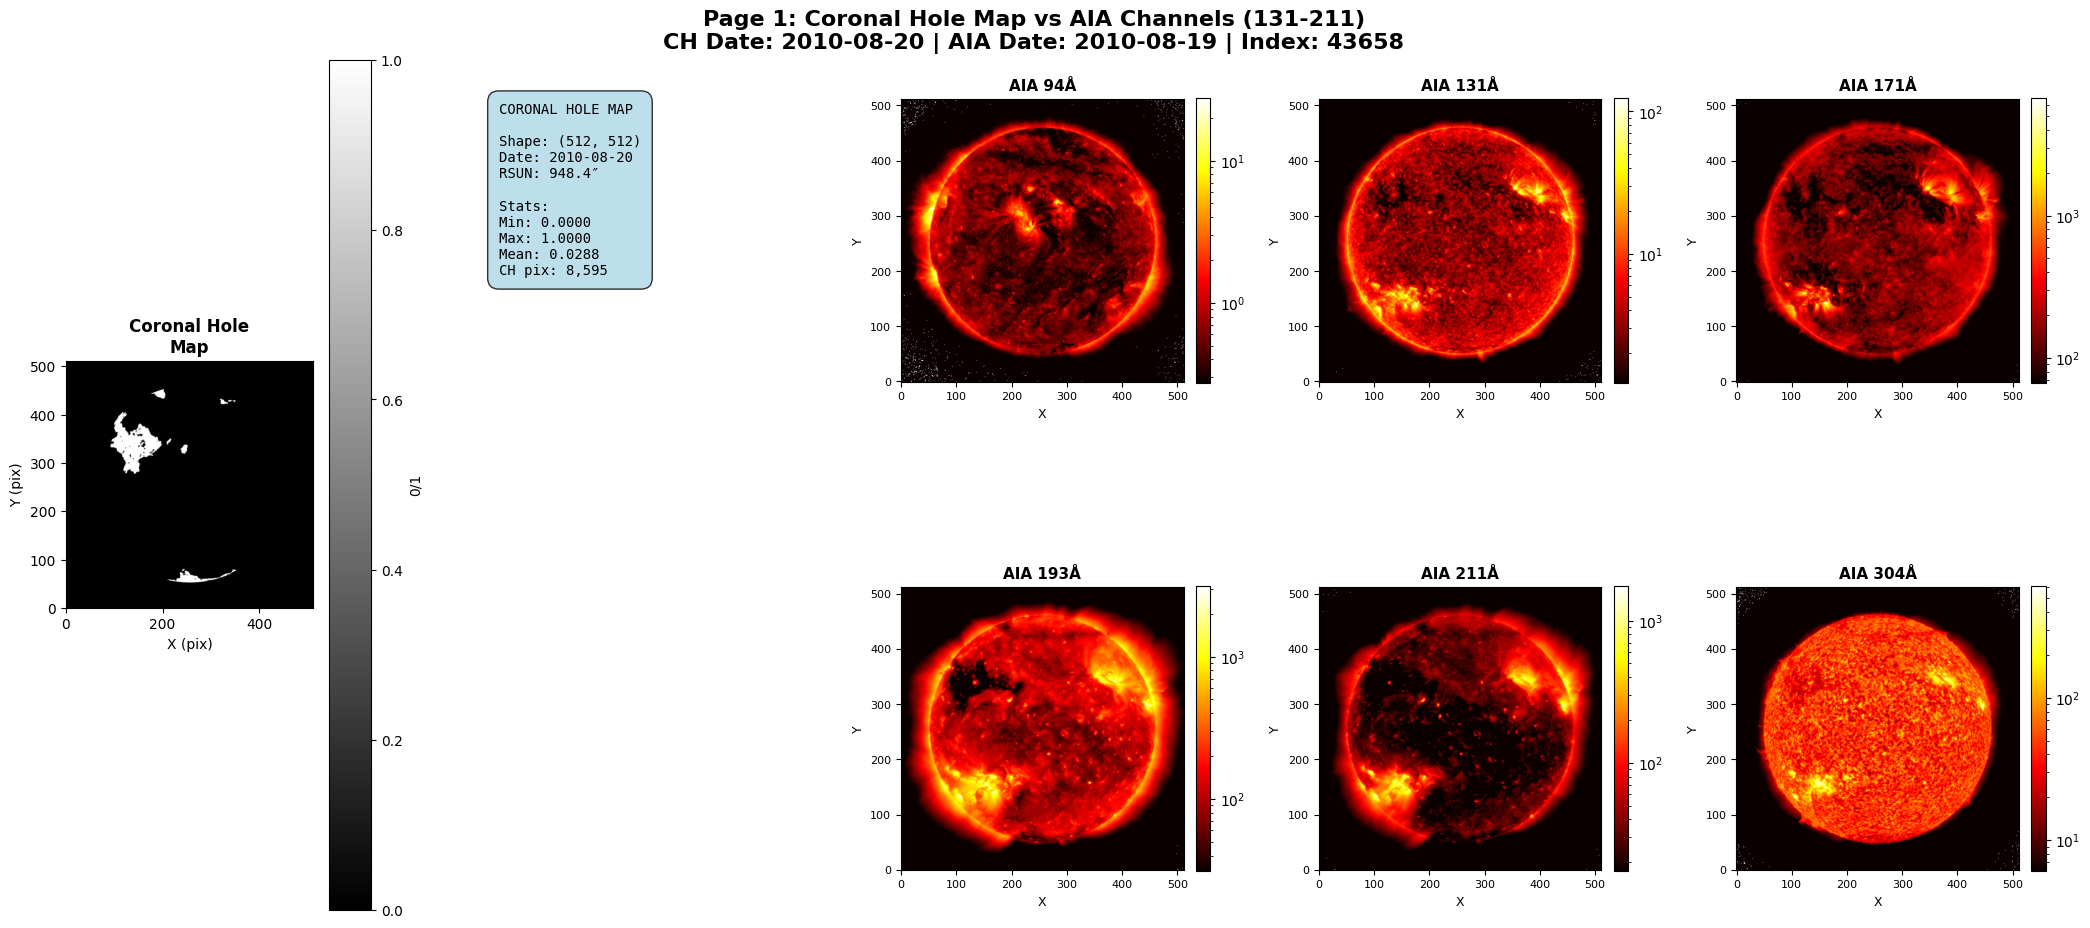

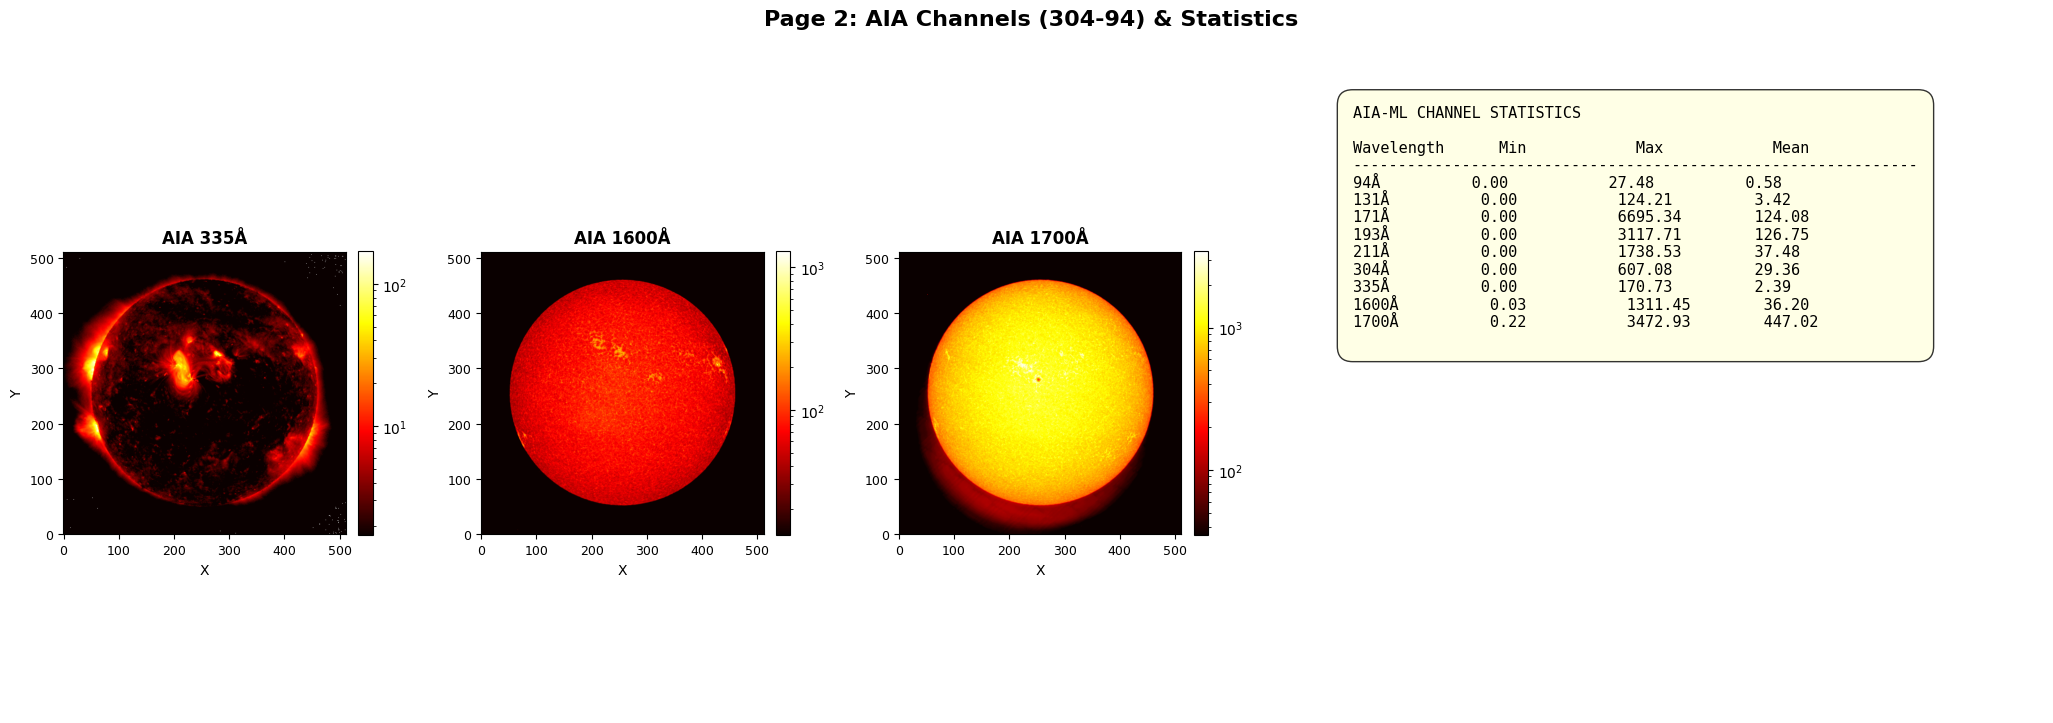

In [ ]:
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import skimage.transform
import s3fs
import zarr
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

trgtAS = 976.0
CHANNELS = [131, 1600, 1700, 171, 193, 211, 304, 335, 94]


def s3_connection(path_to_zarr: str) -> s3fs.S3Map:
    """Create an S3 connection for zarr access"""
    s3 = s3fs.S3FileSystem(anon=True)
    return s3fs.S3Map(root=path_to_zarr, s3=s3)


def load_single_aws_zarr(path_to_zarr: str) -> zarr.Array | zarr.Group:
    """Load zarr from S3"""
    store = s3_connection(path_to_zarr)
    return zarr.open(store=store, mode="r")


def convert_ch_map_to_aiaml(ch_fits_file, trgtAS=976, divideFactor=None, correction=1.0):
    """
    Convert binary coronal hole maps to AIA-ML format.
    Uses the exact same pipeline as AIA images.

    Parameters:
    -----------
    ch_fits_file : str
        Path to the coronal hole FITS file
    trgtAS : float
        Target arcseconds (default 976 for AIA-ML)
    divideFactor : int
        Downsampling factor (auto-detect if None)
    correction : float
        Correction factor (default 1.0)

    Returns:
    --------
    ch_ml : ndarray
        Processed coronal hole map (float32)
    header : dict
        FITS header
    """

    with fits.open(ch_fits_file) as hdul:
        # Get the segmentation map
        segmentation = hdul['CoronalHoleMap'].data
        header = hdul['CoronalHoleMap'].header

        # Auto-detect divide factor if not specified
        if divideFactor is None:
            input_size = segmentation.shape[0]
            target_size = 512
            divideFactor = input_size // target_size

        # Extract binary CH map: ALL non-zero = coronal hole
        X = (segmentation > 0).astype(float)

        print("=" * 70)
        print("CONVERTING CH MAP TO AIA-ML FORMAT")
        print("=" * 70)
        print(f"Input shape: {X.shape}")
        print(f"Detected divide factor: {divideFactor}")
        print(f"Expected output: {X.shape[0] // divideFactor}×{X.shape[1] // divideFactor}")
        print(f"CH pixels (1): {(X == 1).sum():,}")
        print(f"Background pixels (0): {(X == 0).sum():,}")

        # Create validity mask
        # For CH maps, all pixels are valid (no off-disc data)
        validMask = np.ones_like(X)

        # Get metadata
        rad = header['RSUN_OBS']  # Solar radius in arcseconds
        scale_factor = trgtAS / rad

        print(f"\nMetadata:")
        print(f"  RSUN_OBS: {rad:.4f} arcsec")
        print(f"  Target AS: {trgtAS}")
        print(f"  Scale factor: {scale_factor:.6f}")

        # Calculate translation for centering
        t = (X.shape[0] / 2.0) - scale_factor * (X.shape[0] / 2.0)

        # Create similarity transformation
        XForm = skimage.transform.SimilarityTransform(
            scale=scale_factor,
            translation=(t, t)
        )

        print(f"  Translation: ({t:.4f}, {t:.4f})")

        # Apply transformation to CH map
        Xr = skimage.transform.warp(
            X,
            XForm.inverse,
            preserve_range=True,
            mode='edge',
            output_shape=(X.shape[0], X.shape[0])
        )

        # Apply same transformation to validity mask
        Xm = skimage.transform.warp(
            validMask,
            XForm.inverse,
            preserve_range=True,
            mode='edge',
            output_shape=(X.shape[0], X.shape[0])
        )

        # Normalize by validity mask
        Xr = np.divide(Xr, (Xm + 1e-8))

        # Apply correction factor
        Xr = Xr / correction

        print(f"\nAfter transformation:")
        print(f"  Shape: {Xr.shape}")
        print(f"  Min: {np.nanmin(Xr):.6f}")
        print(f"  Max: {np.nanmax(Xr):.6f}")
        print(f"  Mean: {np.nanmean(Xr):.6f}")

        # Downsampling
        Xr = skimage.transform.downscale_local_mean(
            Xr,
            (divideFactor, divideFactor)
        )

        print(f"\nAfter downsampling (factor={divideFactor}):")
        print(f"  Final shape: {Xr.shape}")
        print(f"  Min: {np.nanmin(Xr):.6f}")
        print(f"  Max: {np.nanmax(Xr):.6f}")
        print(f"  Mean: {np.nanmean(Xr):.6f}")

        # Convert to float32
        Xr = Xr.astype('float32')

        print("\n✓ Conversion complete!")
        print("=" * 70)

        return Xr, header


def find_matching_sdoml_dates(ch_date_str):
    """Find matching dates in SDOML 2010"""

    print(f"\n[1] Finding SDOML 2010 dates matching: {ch_date_str}")

    AWS_ZARR_ROOT = (
        "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010"
    )

    try:
        root = load_single_aws_zarr(AWS_ZARR_ROOT)
        aia_array = root['171A']

        attrs = dict(aia_array.attrs)
        if 'DATE-OBS' in attrs:
            date_obs_list = [str(d) for d in attrs['DATE-OBS']]
            cal_dates = [d.split('T')[0] for d in date_obs_list]

            matching_indices = [i for i, d in enumerate(cal_dates) if d == ch_date_str]

            if matching_indices:
                print(f"  ✓ Found {len(matching_indices)} observations on {ch_date_str}")
                return matching_indices
            else:
                unique_dates = sorted(set(cal_dates))
                ch_dt = datetime.fromisoformat(ch_date_str)
                closest_date = min(unique_dates,
                                 key=lambda x: abs((datetime.fromisoformat(x) - ch_dt).days))
                closest_indices = [i for i, d in enumerate(cal_dates) if d == closest_date]

                print(f"  Using closest date: {closest_date}")
                return closest_indices

    except Exception as e:
        print(f"  ⚠ Error: {e}")
        return None


def compare_ch_with_all_channels(ch_fits_file):
    """Compare CH map with all AIA-ML channels"""

    print("=" * 80)
    print("COMPARING CH MAP WITH ALL AIA-ML CHANNELS")
    print("=" * 80)

    # Convert CH map using AIA-ML pipeline
    print(f"\n[Step 1/3] Converting CH map using AIA-ML pipeline")
    ch_data, header = convert_ch_map_to_aiaml(ch_fits_file, trgtAS=976)
    ch_date_str = header.get('DATE_OBS', 'Unknown').split('T')[0]

    # Find matching SDOML dates
    print(f"\n[Step 2/3] Finding matching SDOML dates")
    matching_indices = find_matching_sdoml_dates(ch_date_str)
    sample_idx = matching_indices[0] if matching_indices else 0

    # Load AIA-ML data
    print(f"\n[Step 3/3] Loading AIA-ML data from S3")
    AWS_ZARR_ROOT = (
        "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010"
    )

    aia_data_dict = {}
    aia_meta_dict = {}
    aia_date = None

    try:
        root = load_single_aws_zarr(AWS_ZARR_ROOT)

        # Get AIA date
        first_array = root['171A']
        if hasattr(first_array, 'attrs'):
            attrs = dict(first_array.attrs)
            if 'DATE-OBS' in attrs:
                date_obs_list = [str(d) for d in attrs['DATE-OBS']]
                aia_date = date_obs_list[sample_idx].split('T')[0]

        for wl in CHANNELS:
            channel_name = f'{wl}A'
            try:
                aia_array = root[channel_name]
                aia_data = aia_array[sample_idx, :, :]
                aia_data_dict[channel_name] = aia_data
                aia_meta_dict[channel_name] = {
                    'min': float(np.nanmin(aia_data)),
                    'max': float(np.nanmax(aia_data)),
                    'mean': float(np.nanmean(aia_data)),
                    'std': float(np.nanstd(aia_data)),
                }
                print(f"  ✓ {channel_name}: loaded")
            except Exception as e:
                print(f"  ✗ {channel_name}: {str(e)}")

    except Exception as e:
        print(f"  ⚠ Could not load from S3: {e}")
        return None

    # Create visualization
    print(f"\n[4/4] Creating visualization")
    channel_list = sorted(aia_data_dict.keys(), key=lambda x: int(x[:-1]))

    # PAGE 1: CH map + first 6 AIA channels
    fig1 = plt.figure(figsize=(22, 10))
    fig1.suptitle(
        f'Page 1: Coronal Hole Map vs AIA Channels (131-211)\n'
        f'CH Date: {ch_date_str} | AIA Date: {aia_date} | Index: {sample_idx}',
        fontsize=16,
        fontweight='bold',
        y=0.98
    )

    gs1 = fig1.add_gridspec(nrows=2, ncols=5, left=0.06, right=0.96, top=0.93, bottom=0.08,
                            hspace=0.35, wspace=0.35)

    # CH map
    ax_ch = fig1.add_subplot(gs1[0:2, 0])
    im_ch = ax_ch.imshow(ch_data, cmap='gray', origin='lower')
    ax_ch.set_title('Coronal Hole\nMap', fontweight='bold', fontsize=12)
    ax_ch.set_xlabel('X (pix)', fontsize=10)
    ax_ch.set_ylabel('Y (pix)', fontsize=10)
    plt.colorbar(im_ch, ax=ax_ch, label='0/1')

    # Metadata
    ax_meta = fig1.add_subplot(gs1[0:2, 1])
    ax_meta.axis('off')
    metadata_text = f"""CORONAL HOLE MAP

Shape: {ch_data.shape}
Date: {ch_date_str}
RSUN: {header['RSUN_OBS']:.1f}″

Stats:
Min: {np.nanmin(ch_data):.4f}
Max: {np.nanmax(ch_data):.4f}
Mean: {np.nanmean(ch_data):.4f}
CH pix: {(ch_data > 0).sum():,}"""

    ax_meta.text(0.05, 0.95, metadata_text, transform=ax_meta.transAxes,
                 fontfamily='monospace', fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8, pad=0.8))

    # AIA channels 1-6
    for idx in range(6):
        row = idx // 3
        col = (idx % 3) + 2
        ax = fig1.add_subplot(gs1[row, col])

        channel_name = channel_list[idx]
        aia_data = aia_data_dict[channel_name]
        vmax = np.nanmax(aia_data)
        vmin = vmax / 100

        im = ax.imshow(aia_data, cmap='hot', origin='lower',
                       norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))

        wavelength = channel_name[:-1]
        ax.set_title(f'AIA {wavelength}Å', fontweight='bold', fontsize=11)
        ax.set_xlabel('X', fontsize=9)
        ax.set_ylabel('Y', fontsize=9)
        ax.tick_params(labelsize=8)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # PAGE 2: AIA 7-9 + Statistics
    fig2 = plt.figure(figsize=(22, 8))
    fig2.suptitle(
        f'Page 2: AIA Channels (304-94) & Statistics',
        fontsize=16,
        fontweight='bold',
        y=0.98
    )

    gs2 = fig2.add_gridspec(nrows=1, ncols=5, left=0.06, right=0.96, top=0.90, bottom=0.10,
                            wspace=0.35)

    # AIA 7-9
    for idx in range(3):
        ax = fig2.add_subplot(gs2[0, idx])
        channel_name = channel_list[idx + 6]
        aia_data = aia_data_dict[channel_name]
        vmax = np.nanmax(aia_data)
        vmin = vmax / 100

        im = ax.imshow(aia_data, cmap='hot', origin='lower',
                       norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))

        wavelength = channel_name[:-1]
        ax.set_title(f'AIA {wavelength}Å', fontweight='bold', fontsize=12)
        ax.set_xlabel('X', fontsize=10)
        ax.set_ylabel('Y', fontsize=10)
        ax.tick_params(labelsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Statistics
    ax_stats = fig2.add_subplot(gs2[0, 3:5])
    ax_stats.axis('off')

    stats_text = "AIA-ML CHANNEL STATISTICS\n\n"
    stats_text += f"{'Wavelength':<15} {'Min':<14} {'Max':<14} {'Mean':<14}\n"
    stats_text += "-" * 62 + "\n"

    for channel_name in channel_list:
        meta = aia_meta_dict[channel_name]
        wavelength = channel_name[:-1]
        stats_text += (f"{wavelength}Å{' ' * 9} {meta['min']:<14.2f} "
                      f"{meta['max']:<14.2f} {meta['mean']:<14.2f}\n")

    ax_stats.text(0.05, 0.95, stats_text, transform=ax_stats.transAxes,
                 fontfamily='monospace', fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=1))

    return [fig1, fig2]


if __name__ == "__main__":
    figs = compare_ch_with_all_channels('20100820_000000.ch_map.fits')

    if figs:
        figs[0].savefig('ch_vs_aiaml_page1.png', dpi=150, bbox_inches='tight')
        figs[1].savefig('ch_vs_aiaml_page2.png', dpi=150, bbox_inches='tight')

        print("\n" + "=" * 80)
        print("✓ Plots saved:")
        print("  - ch_vs_aiaml_page1.png")
        print("  - ch_vs_aiaml_page2.png")
        print("=" * 80)

        plt.show()

In [16]:
array1, array2 = df

# If they are already NumPy arrays, this works immediately:
print(array1.shape)
print(array2.shape)

(744, 200, 200)
(744,)


In [18]:
array2[468]

datetime.datetime(2010, 8, 20, 12, 0)

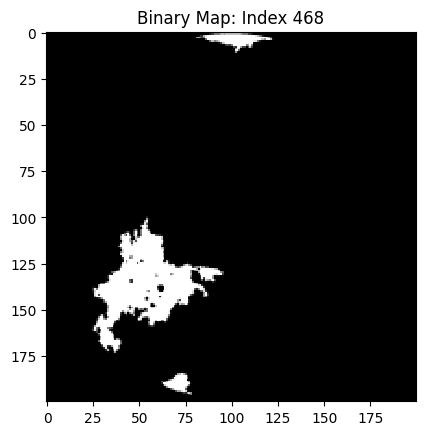

In [22]:
import matplotlib.pyplot as plt

plt.imshow(array1[468], cmap='gray', interpolation='nearest', vmin=0, vmax=1)
plt.title("Binary Map: Index 468")
plt.show()

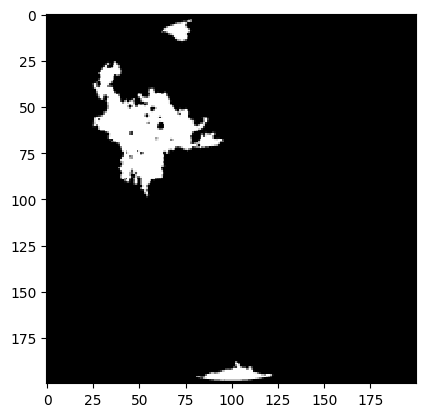

In [23]:
import matplotlib.pyplot as plt

# [::-1] reverses the first dimension (rows/y-axis)
plt.imshow(array1[468][::-1], cmap='gray', interpolation='nearest', vmin=0, vmax=1)
plt.show()

In [1]:
!pip install sunpy[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 967.1/967.1 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.9/110.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.8/105.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.3/350.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━

Querying HEK for SPoCA polygons near 2011-06-07T06:33:02.770...


Found 7 HEK records.
Total Coronal Hole Area: 5320 pixels
Approximate Physical Area: 30714.54 arcsec^2


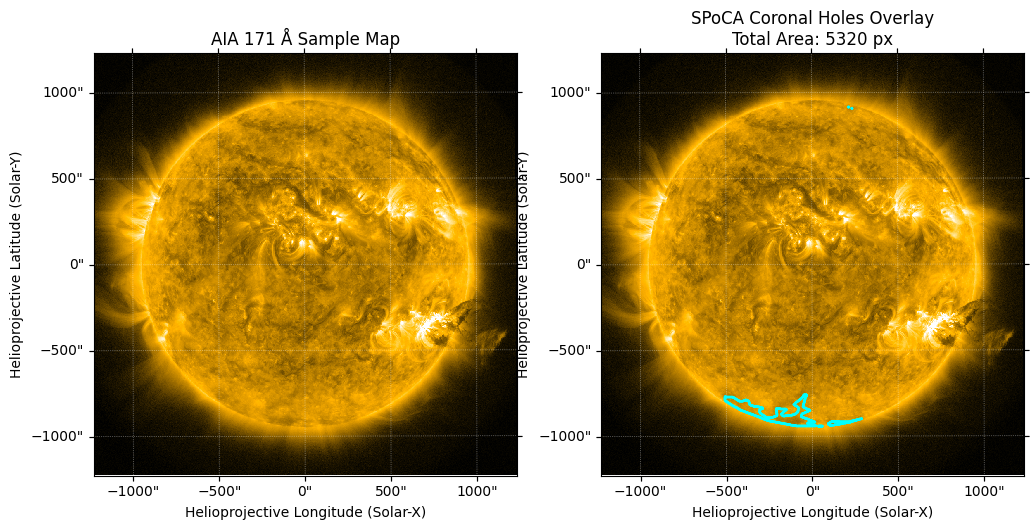

In [156]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import TimeDelta
from astropy.coordinates import SkyCoord
from skimage.draw import polygon

import sunpy.map
import sunpy.data.sample
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate

# ==========================================
# 1. Initialization & Data Fetching
# ==========================================
# Load the SunPy sample AIA 171 image
aia_map = sunpy.map.Map(sunpy.data.sample.AIA_171_IMAGE)
t = 2011-06-07T06:33:02.770
# Query HEK for SPoCA Coronal Holes +/- 2 hours around the image observation time
hek_client = hek.HEKClient()
start_time = aia_map.date - TimeDelta(2 * u.hour)
end_time = aia_map.date + TimeDelta(2 * u.hour)

print(f"Querying HEK for SPoCA polygons near {aia_map.date}...")
responses = hek_client.search(
    a.Time(start_time, end_time),
    a.hek.CH,
    a.hek.FRM.Name == 'SPoCA'
)
print(f"Found {len(responses)} HEK records.")

# ==========================================
# 2. Coordinate Transformation & Rasterization
# ==========================================
# Initialize a blank binary mask matching the AIA map dimensions
binary_mask = np.zeros(aia_map.data.shape, dtype=np.uint8)

for ch_boundary in responses['hpc_boundcc']:
    if not ch_boundary:
        continue

    # Temporal alignment: Rotate SPoCA boundaries to match the AIA image timestamp
    rotated_boundary = solar_rotate_coordinate(ch_boundary, time=aia_map.date)

    # Extract raw arrays
    Tx = rotated_boundary.Tx.value
    Ty = rotated_boundary.Ty.value

    # Sanitize Astropy MaskedNDArrays to standard NumPy arrays
    if hasattr(Tx, 'filled'):
        Tx = Tx.filled(np.nan)
        Ty = Ty.filled(np.nan)

    # Filter out NaNs to prevent skimage polygon from crashing
    valid_mask = ~np.isnan(Tx) & ~np.isnan(Ty)
    if not np.any(valid_mask):
        continue

    # Rebuild a clean SkyCoord
    clean_boundary = SkyCoord(
        Tx[valid_mask] * rotated_boundary.Tx.unit,
        Ty[valid_mask] * rotated_boundary.Ty.unit,
        frame=rotated_boundary.frame
    )

    # Basis Transform: Helioprojective -> Pixel Space
    px, py = aia_map.wcs.world_to_pixel(clean_boundary)

    # Rasterize: Fill the polygon on the discrete grid.
    # skimage expects (rows, cols) which maps to (y, x)
    rr, cc = polygon(py, px, shape=binary_mask.shape)
    binary_mask[rr, cc] = 1

# ==========================================
# 3. Area Calculation & Visualization
# ==========================================
# Calculate physical area based on map scale (arcsec/pixel)
pixel_count = np.count_nonzero(binary_mask)
pixel_area_arcsec2 = aia_map.scale[0].value * aia_map.scale[1].value
total_area_arcsec2 = pixel_count * pixel_area_arcsec2

print(f"Total Coronal Hole Area: {pixel_count} pixels")
print(f"Approximate Physical Area: {total_area_arcsec2:.2f} arcsec^2")

# Plotting: Original Map + Binary Mask Overlay
fig = plt.figure(figsize=(12, 6))

# Left: Original AIA Map
ax1 = fig.add_subplot(121, projection=aia_map)
aia_map.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
ax1.set_title("AIA 171 Å Sample Map")

# Right: Rasterized Mask Overlaid
ax2 = fig.add_subplot(122, projection=aia_map)
aia_map.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
# Overlay the mask using contour to clearly see the boundaries, or imshow with alpha
ax2.contour(binary_mask, colors='cyan', linewidths=1.5)
ax2.set_title(f"SPoCA Coronal Holes Overlay\nTotal Area: {pixel_count} px")

plt.show()

Fetching AIA 193 Å map for 2018-08-21T00:00:00...


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

aia.lev1.193A_2018_08_21T00_00_04.84Z.image_lev1.fits:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Querying HEK for SPoCA polygons near 2018-08-21T00:00:04.840...


Found 6 HEK records.
Total Coronal Hole Area: 114433 pixels
Approximate Physical Area: 41293.98 arcsec^2


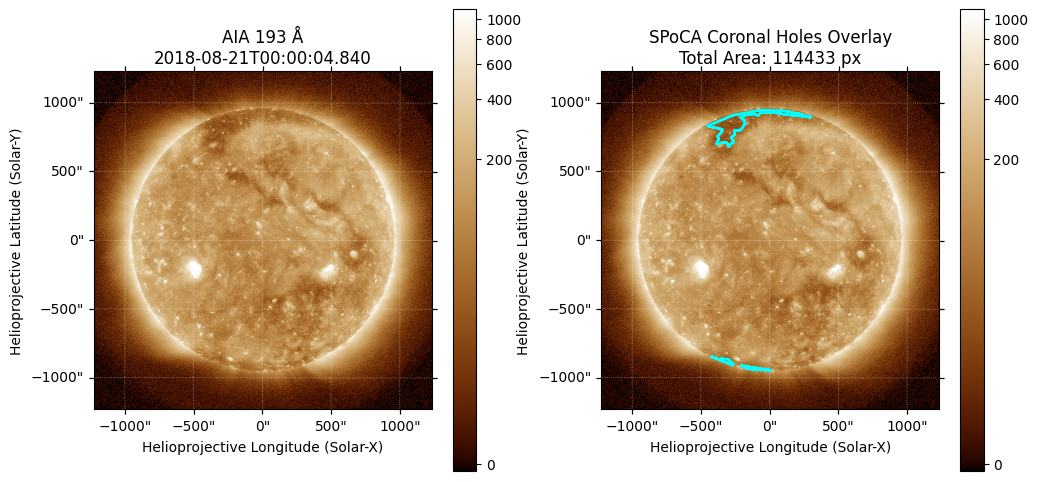

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import TimeDelta
from astropy.coordinates import SkyCoord
from skimage.draw import polygon

import sunpy.map
from sunpy.net import Fido, attrs as a, hek
from sunpy.physics.differential_rotation import solar_rotate_coordinate

# ==========================================
# 1. Fetch Targeted AIA Data
# ==========================================
# Define target time window (1-minute window ensures we catch a frame)
target_start = '2018-08-21T00:00:00'
target_end = '2018-08-21T00:01:00'

print(f"Fetching AIA 193 Å map for {target_start}...")
aia_search = Fido.search(
    a.Time(target_start, target_end),
    a.Instrument.aia,
    a.Wavelength(193 * u.angstrom)
)
# Download the first matching frame
downloaded_files = Fido.fetch(aia_search[0, 0])
aia_map = sunpy.map.Map(downloaded_files[0])

# ==========================================
# 2. Query HEK for SPoCA Polygons
# ==========================================
hek_client = hek.HEKClient()
start_time = aia_map.date - TimeDelta(2 * u.hour)
end_time = aia_map.date + TimeDelta(2 * u.hour)

print(f"Querying HEK for SPoCA polygons near {aia_map.date}...")
responses = hek_client.search(
    a.Time(start_time, end_time),
    a.hek.CH,
    a.hek.FRM.Name == 'SPoCA'
)
print(f"Found {len(responses)} HEK records.")

# ==========================================
# 3. Coordinate Transformation & Rasterization
# ==========================================
binary_mask = np.zeros(aia_map.data.shape, dtype=np.uint8)

for ch_boundary in responses['hpc_boundcc']:
    if not ch_boundary:
        continue

    rotated_boundary = solar_rotate_coordinate(ch_boundary, time=aia_map.date)

    Tx = rotated_boundary.Tx.value
    Ty = rotated_boundary.Ty.value

    if hasattr(Tx, 'filled'):
        Tx = Tx.filled(np.nan)
        Ty = Ty.filled(np.nan)

    valid_mask = ~np.isnan(Tx) & ~np.isnan(Ty)
    if not np.any(valid_mask):
        continue

    clean_boundary = SkyCoord(
        Tx[valid_mask] * rotated_boundary.Tx.unit,
        Ty[valid_mask] * rotated_boundary.Ty.unit,
        frame=rotated_boundary.frame
    )

    px, py = aia_map.wcs.world_to_pixel(clean_boundary)

    rr, cc = polygon(py, px, shape=binary_mask.shape)
    binary_mask[rr, cc] = 1

# ==========================================
# 4. Area Calculation & Visualization
# ==========================================
pixel_count = np.count_nonzero(binary_mask)
pixel_area_arcsec2 = aia_map.scale[0].value * aia_map.scale[1].value
total_area_arcsec2 = pixel_count * pixel_area_arcsec2

print(f"Total Coronal Hole Area: {pixel_count} pixels")
print(f"Approximate Physical Area: {total_area_arcsec2:.2f} arcsec^2")

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection=aia_map)
aia_map.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
ax1.set_title(f"AIA 193 Å\n{aia_map.date}")
plt.colorbar()
ax2 = fig.add_subplot(122, projection=aia_map)
aia_map.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
ax2.contour(binary_mask, colors='cyan', linewidths=1.5)
ax2.set_title(f"SPoCA Coronal Holes Overlay\nTotal Area: {pixel_count} px")
plt.colorbar()
plt.show()

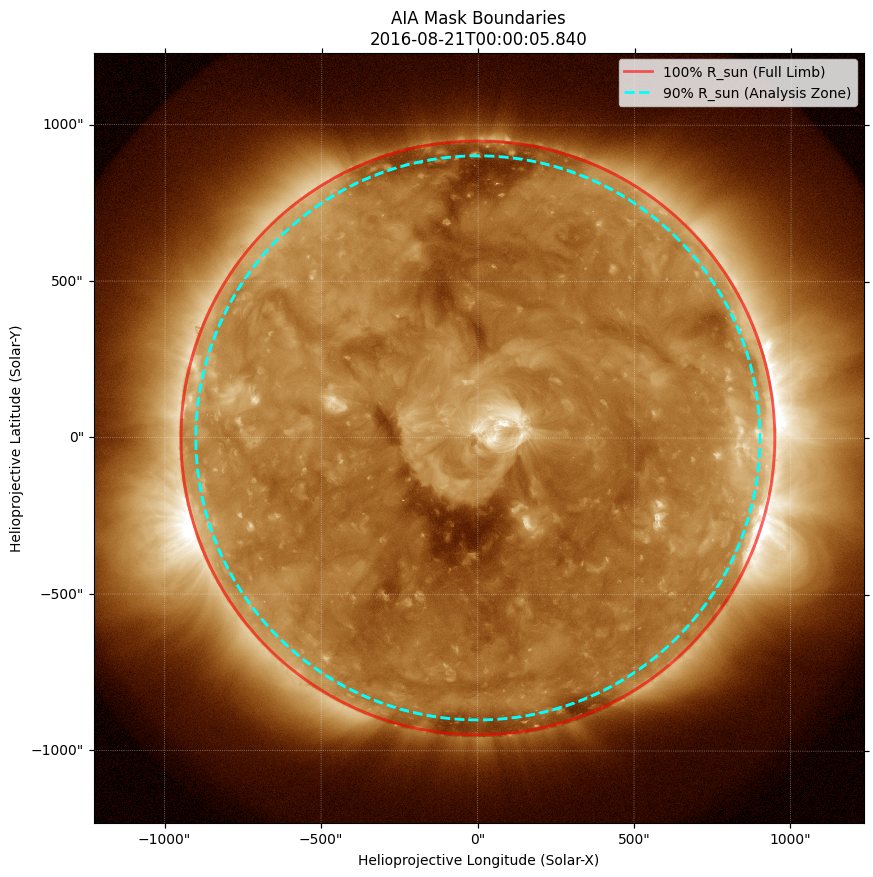

In [179]:
import matplotlib.pyplot as plt
import numpy as np
import sunpy.map
import astropy.units as u
from matplotlib.lines import Line2D

# 1. Generate coordinates and calculate radial distance
hpc_coords = sunpy.map.all_coordinates_from_map(aia_map)
radius = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)

# 2. Define the boolean masks for the full disk and the shrunken disk
full_disk_mask = radius < aia_map.rsun_obs
shrunken_mask = radius < (aia_map.rsun_obs * 0.95)

# 3. Visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=aia_map)

# Plot the base AIA image with standard contrast clipping
aia_map.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)

# Overlay the 100% solar limb in Red
ax.contour(full_disk_mask, colors='red', linewidths=2, alpha=0.6)

# Overlay the 90% shrunken boundary in Cyan (dashed)
ax.contour(shrunken_mask, colors='cyan', linewidths=2, linestyles='dashed')

ax.set_title(f"AIA Mask Boundaries\n{aia_map.date}")

# Add a legend to map the contour colors
legend_elements = [
    Line2D([0], [0], color='red', lw=2, alpha=0.6, label='100% R_sun (Full Limb)'),
    Line2D([0], [0], color='cyan', lw=2, linestyle='dashed', label='90% R_sun (Analysis Zone)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

In [182]:
import numpy as np

# 1. Extract the pixels using boolean indexing
# aia_map.data and binary_mask have the exact same shape (e.g., 4096 x 4096)
ch_pixels = aia_map.data[binary_mask.astype(bool)]

# Sanitize: drop NaNs and negative fill values (common in uncalibrated off-limb regions)
ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

if len(ch_pixels) == 0:
    print("No valid CH pixels found in this timeframe.")
else:
    # 2. Standard Statistics
    ch_mean = np.mean(ch_pixels)
    ch_median = np.median(ch_pixels)
    ch_min = np.min(ch_pixels)

    # 3. Robust Metric: Mean of the 1st Quartile (darkest 25%)
    q1_threshold = np.percentile(ch_pixels, 25)
    mean_darkest_25 = np.mean(ch_pixels[ch_pixels <= q1_threshold])

    print(f"Mean: {ch_mean:.2f}")
    print(f"Median: {ch_median:.2f}")
    print(f"Minimum: {ch_min:.2f}")
    print(f"Mean of Darkest 25%: {mean_darkest_25:.2f}")

Mean: 59.08
Median: 51.00
Minimum: 8.00
Mean of Darkest 25%: 29.79


In [183]:
# 1. Generate coordinates and calculate radial distance
hpc_coords = sunpy.map.all_coordinates_from_map(aia_map)
radius = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)

# 2. Shrink the radius to exclude the limb (e.g., use the inner 95%)
scale_factor = 0.95
shrunken_rsun = aia_map.rsun_obs * scale_factor

# 3. Create the stricter mask
disk_mask = radius < shrunken_rsun

# 4. Compute the Quiet Sun baseline on the central disk only
qs_median = np.nanmedian(aia_map.data[disk_mask])

print(f"Computed QS Median (Inner {scale_factor*100}% of disk): {qs_median:.2f}")

Computed QS Median (Inner 95.0% of disk): 179.00


In [77]:
aia_map = sunpy.map.Map(sunpy.data.sample.AIA_171_IMAGE)

In [78]:
hek_client = hek.HEKClient()
start_time = aia_map.date - TimeDelta(2*u.hour)
end_time = aia_map.date + TimeDelta(2*u.hour)
responses = hek_client.search(a.Time(start_time, end_time),
                              a.hek.CH, a.hek.FRM.Name == 'SPoCA')
print(responses.colnames)

['gs_thumburl', 'comment_count', 'hpc_bbox', 'frm_humanflag', 'hgc_coord', 'obs_levelnum', 'hpc_coord', 'event_npixels', 'gs_imageurl', 'ar_polarity', 'frm_paramset', 'hrc_coord', 'event_starttime', 'ar_mtwilsoncls', 'event_type', 'intensmin', 'obs_meanwavel', 'frm_url', 'skel_chaincode', 'bound_chaincode', 'noposition', 'active', 'intensmax', 'frm_versionnumber', 'area_uncert', 'obs_dataprepurl', 'hpc_geom', 'hgc_bbox', 'intensmedian', 'chaincodetype', 'obs_channelid', 'event_clippedspatial', 'ar_noaaclass', 'SOL_standard', 'event_avg_rating', 'eventtype', 'hpc_boundcc', 'event_mapurl', 'frm_contact', 'ar_penumbracls', 'intensmean', 'bound_ccstartc1', 'frm_name', 'area_atdiskcenter', 'frm_identifier', 'obs_observatory', 'event_description', 'boundbox_c2ur', 'obs_firstprocessingdate', 'boundbox_c2ll', 'frm_institute', 'hrc_bbox', 'refs_orig', 'hrc_skeletoncc', 'ar_mcintoshcls', 'event_maskurl', 'bound_ccstartc2', 'gs_movieurl', 'event_score', 'skel_startc2', 'skel_startc1', 'event_expi

In [79]:
area = 0.0
for i, response in enumerate(responses):
    if response['area_atdiskcenter'] > area and np.abs(response['hgc_y']) < 80.0:
        area = response['area_atdiskcenter']
        response_index = i

In [152]:
ch = responses[response_index]
ch_boundary = responses[response_index]["hpc_boundcc"]

In [153]:
rotated_ch_boundary = solar_rotate_coordinate(ch_boundary, time=aia_map.date)

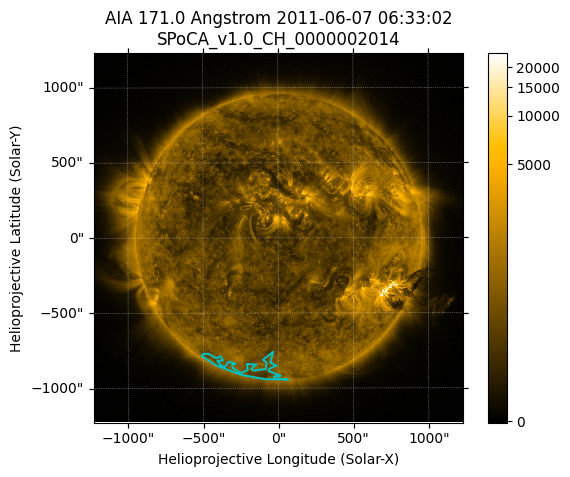

In [154]:
fig = plt.figure()
ax = fig.add_subplot(projection=aia_map)
aia_map.plot(axes=ax, clip_interval=(1, 99.99)*u.percent)
ax.plot_coord(rotated_ch_boundary, color='c')
ax.set_title('{:s}\n{:s}'.format(aia_map.name, ch['frm_specificid']))
plt.colorbar()

plt.show()

In [2]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.time import TimeDelta
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
import sunpy.map
from sunpy.net import Fido, attrs as a, hek
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import os

# ==========================================
# 1. Configuration & Time Range
# ==========================================
dates = pd.date_range(start='2018-01-01', end='2018-12-31', freq='D')
results = []
output_file = "ch_metrics_2018.csv"

# Pre-initialize HEK Client
hek_client = hek.HEKClient()

for date in dates:
    target_time = date.strftime('%Y-%m-%dT%H:%M:%S')
    print(f"Processing: {target_time}")

    try:
        # 2. Fetch AIA 193 Å Map
        # Search window: 10 mins to ensure we catch a frame
        search = Fido.search(
          a.Time(date, date + pd.Timedelta(minutes=20)),
          a.Instrument.aia,
          a.Wavelength(193 * u.angstrom)
      )
        if not search:
            print(f"No AIA data for {target_time}")
            continue

        file = Fido.fetch(search[0, 0], progress=False)
        aia_map = sunpy.map.Map(file[0])

        # 3. Fetch HEK SPoCA Polygons
        start_search = aia_map.date - TimeDelta(2 * u.hour)
        end_search = aia_map.date + TimeDelta(2 * u.hour)
        responses = hek_client.search(
            a.Time(start_search, end_search),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # 4. Generate QS Median (90% Shrunken Disk)
        hpc_coords = sunpy.map.all_coordinates_from_map(aia_map)
        radius = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        shrunken_mask = radius < (aia_map.rsun_obs * 0.90)
        qs_median = np.nanmedian(aia_map.data[shrunken_mask])

        # 5. Rasterize CH Mask
        binary_mask = np.zeros(aia_map.data.shape, dtype=np.uint8)
        if len(responses) > 0:
            for ch_boundary in responses['hpc_boundcc']:
                if not ch_boundary: continue
                rotated = solar_rotate_coordinate(ch_boundary, time=aia_map.date)
                tx, ty = rotated.Tx.value, rotated.Ty.value
                if hasattr(tx, 'filled'):
                    tx, ty = tx.filled(np.nan), ty.filled(np.nan)
                valid = ~np.isnan(tx) & ~np.isnan(ty)
                if not np.any(valid): continue

                clean_coord = SkyCoord(tx[valid]*rotated.Tx.unit, ty[valid]*rotated.Ty.unit, frame=rotated.frame)
                px, py = aia_map.wcs.world_to_pixel(clean_coord)
                rr, cc = polygon(py, px, shape=binary_mask.shape)
                binary_mask[rr, cc] = 1

        # 6. Extract CH Statistics
        ch_pixels = aia_map.data[binary_mask.astype(bool)]
        ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

        if len(ch_pixels) > 0:
            ch_mean = np.mean(ch_pixels)
            ch_median = np.median(ch_pixels)
            ch_min = np.min(ch_pixels)
            q1_threshold = np.percentile(ch_pixels, 25)
            mean_darkest_25 = np.mean(ch_pixels[ch_pixels <= q1_threshold])
        else:
            ch_mean = ch_median = ch_min = mean_darkest_25 = np.nan

        # 7. Store Result
        results.append({
            'date': target_time,
            'qs_median': qs_median,
            'ch_mean': ch_mean,
            'ch_median': ch_median,
            'ch_min': ch_min,
            'mean_darkest_25': mean_darkest_25,
            'pixel_count': len(ch_pixels)
        })

        # Cleanup downloaded file to save disk space
        if os.path.exists(file[0]): os.remove(file[0])

    except Exception as e:
        print(f"Error on {target_time}: {e}")

# ==========================================
# 8. Export Data
# ==========================================
df_results = pd.DataFrame(results)
df_results.to_csv(output_file, index=False)
print(f"Data saved to {output_file}")

Processing: 2018-01-01T00:00:00


Processing: 2018-01-02T00:00:00


Processing: 2018-01-03T00:00:00


Processing: 2018-01-04T00:00:00


Processing: 2018-01-05T00:00:00


...

Processing: 2018-01-17T00:00:00


Processing: 2018-01-18T00:00:00


Processing: 2018-01-19T00:00:00


Processing: 2018-01-20T00:00:00


KeyboardInterrupt: 

In [3]:
import os
import numpy as np
import pandas as pd
import astropy.units as u
from tqdm.auto import tqdm
import sunpy.map
from sunpy.net import Fido, attrs as a, hek
from skimage.draw import polygon
from astropy.coordinates import SkyCoord
from sunpy.physics.differential_rotation import solar_rotate_coordinate

# 1. Batch Search with explicit Provider
print("Searching JSOC...")
search_results = Fido.search(
    a.Time("2018-01-01T00:00:00", "2018-12-31T23:59:59"),
    a.Instrument.aia,
    a.Wavelength(193 * u.angstrom),
    a.Sample(24 * u.hour),
    a.Provider.jsoc  # Forcing JSOC often fixes empty VSO returns
)

# Check if search_results is empty before proceeding
if not search_results:
    print("Error: No data found for the specified time range. JSOC or VSO might be down.")
else:
    # 2. Batch Download
    print(f"Found {len(search_results[0])} files. Downloading in parallel...")
    files = Fido.fetch(search_results, max_conn=12, progress=True)

    if not files:
        print("Download failed or returned no files.")
    else:
        files.sort()
        # ... proceed to processing loop ...

# 2. Batch Download (High Concurrency)
# max_conn=12 is usually the sweet spot for Colab's bandwidth
print(f"Downloading {len(search_results[0])} files in parallel...")
files = Fido.fetch(search_results, max_conn=12, progress=True)
files.sort() # Ensure chronological order

# 3. Iterative Processing
hek_client = hek.HEKClient()
all_metrics = []

for f_path in tqdm(files, desc="Processing FITS"):
    try:
        smap = sunpy.map.Map(f_path)
        obs_time = smap.date

        # --- Quiet Sun Median (90% Disk) ---
        hpc_coords = sunpy.map.all_coordinates_from_map(smap)
        r = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_median = np.nanmedian(smap.data[r < (smap.rsun_obs * 0.90)])

        # --- SPoCA Rasterization ---
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        mask = np.zeros(smap.data.shape, dtype=np.uint8)
        for ch in res:
            bound = ch['hpc_boundcc']
            if not bound: continue
            rot = solar_rotate_coordinate(bound, time=obs_time)
            tx, ty = rot.Tx.value, rot.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            v = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(v): continue

            clean = SkyCoord(tx[v]*u.arcsec, ty[v]*u.arcsec, frame=rot.frame)
            px, py = smap.wcs.world_to_pixel(clean)
            rr, cc = polygon(py, px, shape=mask.shape)
            mask[rr, cc] = 1

        # --- Metric Extraction ---
        ch_pix = smap.data[mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        m = {'date': obs_time.iso, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            m.update({
                'ch_mean': np.mean(ch_pix),
                'ch_median': np.median(ch_pix),
                'ch_min': np.min(ch_pix),
                'mean_darkest_25': np.mean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
            })
        else:
            m.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25']})

        all_metrics.append(m)

        # CRITICAL: Delete FITS after processing to save Colab disk space
        os.remove(f_path)

    except Exception as e:
        print(f"Error processing {f_path}: {e}")

# 4. Save results
pd.DataFrame(all_metrics).to_csv("ch_metrics_2018.csv", index=False)

Searching JSOC...
Found 365 files. Downloading in parallel...


Files Downloaded:   0%|          | 0/365 [00:00<?, ?file/s]

aia.lev1.193A_2018_01_03T00_00_04.83Z.image_lev1.fits:   0%|          | 0.00/11.0M [00:00<?, ?B/s]

aia.lev1.193A_2018_01_06T00_00_04.83Z.image_lev1.fits:   0%|          | 0.00/10.9M [00:00<?, ?B/s]

aia.lev1.193A_2018_01_07T00_00_04.84Z.image_lev1.fits:   0%|          | 0.00/11.0M [00:00<?, ?B/s]

...

aia.lev1.193A_2018_01_28T00_00_04.84Z.image_lev1.fits:   0%|          | 0.00/10.9M [00:00<?, ?B/s]

71/0 files failed to download. Please check `.errors` for details


Files Downloaded:   0%|          | 0/365 [00:00<?, ?file/s]

12/0 files failed to download. Please check `.errors` for details


Processing FITS: 0it [00:00, ?it/s]

Closest Zarr observation found at: 2018-08-21 00:00:04.840000


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs




--- Metrics ---
ch_mean: 33.57
ch_median: 30.10
ch_min: 16.35
mean_darkest_25: 22.22
qs_median: 101.14


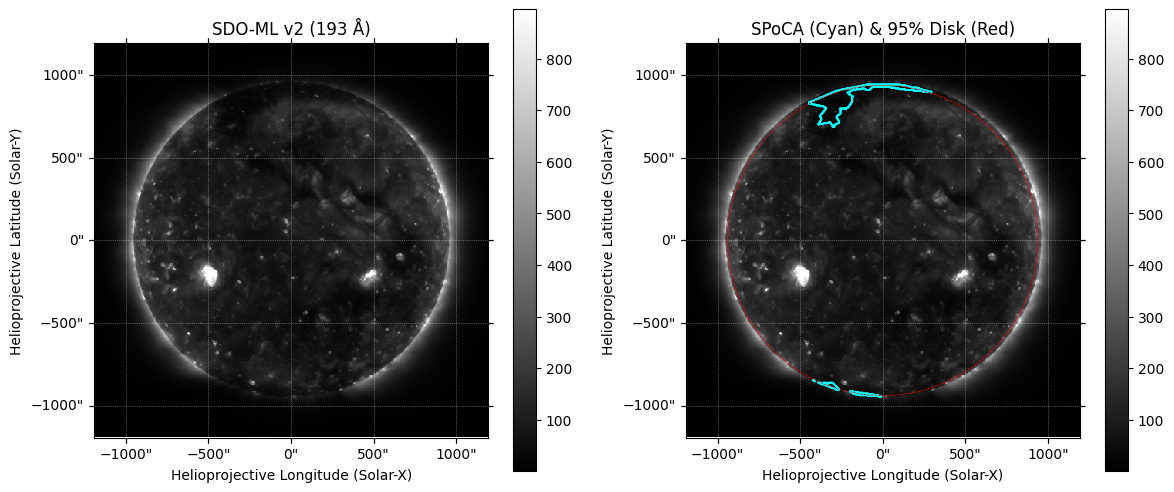

In [10]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
import matplotlib.pyplot as plt

# 1. Setup S3 Connection for 2016
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2016 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
store = s3fs.S3Map(root=AWS_ZARR_2016, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Find closest index to 2016-08-21T00:00:00
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_time = pd.Timestamp('2018-08-21T00:00:00')
idx = np.argmin(np.abs(zarr_times - target_time))
obs_time = zarr_times[idx]
print(f"Closest Zarr observation found at: {obs_time}")

# 3. Create Synthetic SunPy Map from Zarr Metadata
# This is required for the WCS world_to_pixel transformation
header = {
    'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
    'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
    'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
    'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
    'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
    'DATE-OBS': obs_time.isoformat(),
    'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
    'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
}
img_data = data_193[idx]
sdoml_map = sunpy.map.Map(img_data, header)

# 4. Fetch SPoCA Polygons from HEK
hek_client = hek.HEKClient()
res = hek_client.search(
    a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
    a.hek.CH, a.hek.FRM.Name == 'SPoCA'
)

# 5. Rasterize CH Mask with Sanitization
binary_mask = np.zeros(img_data.shape, dtype=np.uint8)

for ch_boundary in res['hpc_boundcc']:
    if not ch_boundary: continue

    # Temporal Alignment
    rotated = solar_rotate_coordinate(ch_boundary, time=obs_time)

    # SANITIZATION: Handle MaskedNDArray (TypeError Fix)
    tx, ty = rotated.Tx.value, rotated.Ty.value
    if hasattr(tx, 'filled'):
        tx, ty = tx.filled(np.nan), ty.filled(np.nan)

    valid = ~np.isnan(tx) & ~np.isnan(ty)
    if not np.any(valid): continue

    # Rebuild clean SkyCoord for WCS
    clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
    px, py = sdoml_map.wcs.world_to_pixel(clean_coord)

    # Draw Polygon (Row, Col = Y, X)
    rr, cc = polygon(py, px, shape=binary_mask.shape)
    binary_mask[rr, cc] = 1

# 6. Calculate Metrics
# Quiet Sun Median (95% Shrunken Disk)
hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
qs_median = np.nanmedian(img_data[qs_mask])

# Coronal Hole Metrics
ch_pix = img_data[binary_mask.astype(bool)]
ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

if len(ch_pix) > 0:
    metrics = {
        'ch_mean': np.nanmean(ch_pix),
        'ch_median': np.nanmedian(ch_pix),
        'ch_min': np.nanmin(ch_pix),
        'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
        'qs_median': qs_median
    }
else:
    metrics = {k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'qs_median']}

# 7. Visualization & Verification
print("\n--- Metrics ---")
for k, v in metrics.items(): print(f"{k}: {v:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': sdoml_map})
sdoml_map.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
ax1.set_title("SDO-ML v2 (193 Å)")
plt.colorbar()

sdoml_map.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
ax2.contour(binary_mask, colors='cyan', linewidths=1)
ax2.contour(qs_mask, colors='red', linestyles='dashed', linewidths=0.5)
ax2.set_title("SPoCA (Cyan) & 95% Disk (Red)")
plt.colorbar()
plt.show()


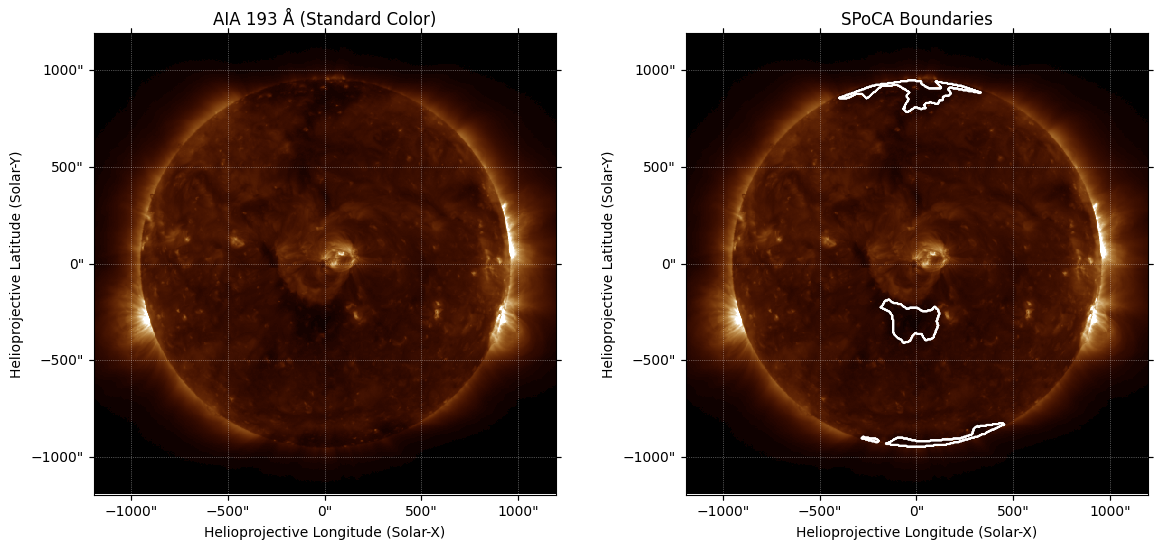

In [7]:
import sunpy.visualization.colormaps as cm

# 1. Fetch the official AIA 193 color table
aia193_cmap = plt.get_cmap('sdoaia193')

# 2. Apply it in your plot call
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': sdoml_map})

# Use cmap and a log-normalization for better contrast
sdoml_map.plot(axes=ax1, cmap=aia193_cmap, clip_interval=(1, 99.9)*u.percent)
ax1.set_title("AIA 193 Å (Standard Color)")

sdoml_map.plot(axes=ax2, cmap=aia193_cmap, clip_interval=(1, 99.9)*u.percent)
ax2.contour(binary_mask, colors='white', linewidths=1) # White contrast better on bronze
ax2.set_title("SPoCA Boundaries")

plt.show()

In [9]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
from tqdm.auto import tqdm

# 1. Setup S3 Connection for 2018
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2018 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
store = s3fs.S3Map(root=AWS_ZARR_2018, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2018-01-01', end='2018-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2018_daily.csv"

for day in tqdm(target_days, desc="Processing 2018"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2018:   0%|          | 0/365 [00:00<?, ?it/s]

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Processing complete. Data saved to ch_metrics_2018_daily.csv


In [12]:
df = pd.read_csv("ch_metrics_2018_daily.csv")

# Convert to datetime to ensure accurate filtering
df['date'] = pd.to_datetime(df['date'])

# Filter for August 21, 2018
target_row = df[df['date'].dt.date == pd.to_datetime('2018-08-21').date()]

# Display the result
if not target_row.empty:
    print(target_row.to_string(index=False))
else:
    print("No data found for 2018-08-21. Check if there was a data gap or processing error.")

                   date  qs_median   ch_mean  ch_median    ch_min  mean_darkest_25  ch_pixel_count
2018-08-21 00:00:04.840   99.35915 33.573193   30.09887 16.345531        22.218454            1900


In [14]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
from tqdm.auto import tqdm

# 1. Setup S3 Connection for 2015
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2015 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2015"
store = s3fs.S3Map(root=AWS_ZARR_2015, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2015-01-01', end='2015-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2015_daily.csv"

for day in tqdm(target_days, desc="Processing 2015"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2015:   0%|          | 0/365 [00:00<?, ?it/s]

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Processing complete. Data saved to ch_metrics_2015_daily.csv


In [15]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
from tqdm.auto import tqdm

# 1. Setup S3 Connection for 2010
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2010 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010"
store = s3fs.S3Map(root=AWS_ZARR_2010, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2010-01-01', end='2010-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2010_daily.csv"

for day in tqdm(target_days, desc="Processing 2010"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2010:   0%|          | 0/365 [00:00<?, ?it/s]

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Processing complete. Data saved to ch_metrics_2010_daily.csv


In [16]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
from tqdm.auto import tqdm

# 1. Setup S3 Connection for 2011
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2011 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2011"
store = s3fs.S3Map(root=AWS_ZARR_2011, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2011-01-01', end='2011-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2011_daily.csv"

for day in tqdm(target_days, desc="Processing 2011"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2011:   0%|          | 0/365 [00:00<?, ?it/s]

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Processing complete. Data saved to ch_metrics_2011_daily.csv


In [17]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
from tqdm.auto import tqdm

# 1. Setup S3 Connection for 2012
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2012 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2012"
store = s3fs.S3Map(root=AWS_ZARR_2012, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2012-01-01', end='2012-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2012_daily.csv"

for day in tqdm(target_days, desc="Processing 2012"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2012:   0%|          | 0/366 [00:00<?, ?it/s]

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Processing complete. Data saved to ch_metrics_2012_daily.csv


In [18]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
from tqdm.auto import tqdm

# 1. Setup S3 Connection for 2013
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2013 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2013"
store = s3fs.S3Map(root=AWS_ZARR_2013, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2013-01-01', end='2013-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2013_daily.csv"

for day in tqdm(target_days, desc="Processing 2013"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2013:   0%|          | 0/365 [00:00<?, ?it/s]

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Processing complete. Data saved to ch_metrics_2013_daily.csv


In [19]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
from tqdm.auto import tqdm

# 1. Setup S3 Connection for 2014
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2014 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2014"
store = s3fs.S3Map(root=AWS_ZARR_2014, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2014-01-01', end='2014-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2014_daily.csv"

for day in tqdm(target_days, desc="Processing 2014"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2014:   0%|          | 0/365 [00:00<?, ?it/s]

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Error on 2014-12-19 00:00:07.620000: Failed to load return from the HEKClient.


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Processing complete. Data saved to ch_metrics_2014_daily.csv


In [20]:
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
from tqdm.auto import tqdm

# 1. Setup S3 Connection for 2016
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2016 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2016"
store = s3fs.S3Map(root=AWS_ZARR_2016, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2016-01-01', end='2016-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2016_daily.csv"

for day in tqdm(target_days, desc="Processing 2016"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2016:   0%|          | 0/366 [00:00<?, ?it/s]

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crln_obs,crlt_obs

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: dsu

Processing complete. Data saved to ch_metrics_2016_daily.csv


In [78]:
# 1. Setup S3 Connection for 2017
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2017 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2017"
store = s3fs.S3Map(root=AWS_ZARR_2011, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2017-01-01', end='2017-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2017_daily.csv"

for day in tqdm(target_days, desc="Processing 2017"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

NameError: name 's3fs' is not defined

In [22]:
# 1. Setup S3 Connection for 2018
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2018 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
store = s3fs.S3Map(root=AWS_ZARR_2011, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2018-01-01', end='2018-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2018_daily.csv"

for day in tqdm(target_days, desc="Processing 2018"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2018:   0%|          | 0/365 [00:00<?, ?it/s]

Processing complete. Data saved to ch_metrics_2018_daily.csv


In [23]:
# 1. Setup S3 Connection for 2019
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2019 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2019"
store = s3fs.S3Map(root=AWS_ZARR_2011, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Extract Zarr Timestamps and Generate Daily Target Dates
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_days = pd.date_range(start='2019-01-01', end='2019-12-31', freq='D')

# 3. Initialization
hek_client = hek.HEKClient()
results = []
output_csv = "ch_metrics_2019_daily.csv"

for day in tqdm(target_days, desc="Processing 2019"):
    # Find the closest Zarr index to 00:00 UT for the current day
    idx = np.argmin(np.abs(zarr_times - day))
    obs_time = zarr_times[idx]

    # Skip if the closest match is more than 2 hours away (data gap)
    if abs((obs_time - day).total_seconds()) > 7200:
        continue

    try:
        # Construct Synthetic Map Header
        header = {
            'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
            'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
            'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
            'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
            'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
            'DATE-OBS': obs_time.isoformat(),
            'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
            'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
        }
        img_data = data_193[idx]
        sdoml_map = sunpy.map.Map(img_data, header)

        # Fetch SPoCA from HEK (±2h window)
        res = hek_client.search(
            a.Time(obs_time - pd.Timedelta(hours=2), obs_time + pd.Timedelta(hours=2)),
            a.hek.CH, a.hek.FRM.Name == 'SPoCA'
        )

        # Rasterize CH Mask
        binary_mask = np.zeros(img_data.shape, dtype=np.uint8)
        for ch in res:
            if not ch['hpc_boundcc']: continue
            rotated = solar_rotate_coordinate(ch['hpc_boundcc'], time=obs_time)
            tx, ty = rotated.Tx.value, rotated.Ty.value
            if hasattr(tx, 'filled'): tx, ty = tx.filled(np.nan), ty.filled(np.nan)
            valid = ~np.isnan(tx) & ~np.isnan(ty)
            if not np.any(valid): continue

            clean_coord = SkyCoord(tx[valid]*u.arcsec, ty[valid]*u.arcsec, frame=rotated.frame)
            px, py = sdoml_map.wcs.world_to_pixel(clean_coord)
            rr, cc = polygon(py, px, shape=binary_mask.shape)
            binary_mask[rr, cc] = 1

        # Calculate Statistics
        # QS Median (95% disk used here for limb stability)
        hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
        r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
        qs_mask = r_dist < (sdoml_map.rsun_obs * 0.95)
        qs_median = np.nanmedian(img_data[qs_mask])

        # CH Metrics
        ch_pix = img_data[binary_mask.astype(bool)]
        ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

        day_results = {'date': obs_time, 'qs_median': qs_median}
        if len(ch_pix) > 0:
            day_results.update({
                'ch_mean': np.nanmean(ch_pix),
                'ch_median': np.nanmedian(ch_pix),
                'ch_min': np.nanmin(ch_pix),
                'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
                'ch_pixel_count': len(ch_pix)
            })
        else:
            day_results.update({k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'ch_pixel_count']})

        results.append(day_results)

    except Exception as e:
        print(f"Error on {obs_time}: {e}")

# 4. Save to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"Processing complete. Data saved to {output_csv}")

Processing 2019:   0%|          | 0/365 [00:00<?, ?it/s]

Processing complete. Data saved to ch_metrics_2019_daily.csv
